# Geopolitical Risk and the Real Economy: Industry-Level Evidence
## From Employment, Prices, and Output During the 2026 Strait of Hormuz Crisis

**Paper:** Examine how geopolitical risk shocks transmit to the US economy at the industry level, using the February 28, 2026 Iran conflict as a natural experiment.

**Data Sources (all free, no premium keys needed):**
- **FRED** — EPU index, oil prices, interest rates, macro indicators
- **yfinance** — Sector ETF daily prices (free, unlimited)
- **BLS** — Employment, CPI, PPI by industry
- **BEA** — GDP by industry
- **Treasury Fiscal Data** — Federal debt, spending

**Analysis:** Event Study, VAR/IRF, Granger Causality, Cross-sectional Regression

---

In [84]:
# ============================================================
# 1.1  Install dependencies
# ============================================================
!pip install pandas numpy requests matplotlib seaborn scipy statsmodels scikit-learn yfinance -q

In [85]:
# ============================================================
# 1.2  Imports and configuration
# ============================================================
import pandas as pd
import numpy as np
import requests
import time
import warnings
import json
from datetime import datetime, timedelta
from io import StringIO

import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import grangercausalitytests, adfuller

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.figsize': (14, 7), 'font.size': 12,
    'axes.titlesize': 14, 'axes.labelsize': 12,
    'figure.dpi': 120, 'savefig.dpi': 300, 'savefig.bbox': 'tight'
})
sns.set_style("whitegrid")
print("All imports successful.")

All imports successful.


In [86]:
# ============================================================
# 1.3  API Keys and Configuration
#      ROBUST: SAMPLE_END = today's date (auto-updates on re-run)
# ============================================================
API_KEYS = {
    'FRED': '5f33ed2b539cfd80cd4a5343654a6fca',
    'BLS':  '5df8024e059b4966a66b69f1224259de',
    'BEA':  '94A4A4DE-3C3B-42F8-9204-6118E0A244DF',
}
# yfinance needs NO API key
# Treasury Fiscal Data needs NO API key

TREASURY_BASE = 'https://api.fiscaldata.treasury.gov/services/api/fiscal_service'

EVENT_DATE   = pd.Timestamp('2026-02-28')
SAMPLE_START = '2023-01-01'
SAMPLE_END   = pd.Timestamp('today').strftime('%Y-%m-%d')  # ← auto-updates
RUN_DATE     = pd.Timestamp('today')

SECTOR_ETFS = {
    'XLE': 'Energy', 'XLF': 'Financials', 'XLI': 'Industrials',
    'XLK': 'Technology', 'XLV': 'Health Care', 'XLC': 'Communication Services',
    'XLB': 'Materials', 'XLRE': 'Real Estate', 'XLU': 'Utilities',
    'XLP': 'Consumer Staples', 'XLY': 'Consumer Discretionary', 'SPY': 'S&P 500',
}

def api_get(url, params=None, retries=3, delay=2):
    """GET with exponential backoff. Returns None on failure."""
    for attempt in range(retries):
        try:
            resp = requests.get(url, params=params, timeout=30)
            if resp.status_code == 400:
                print(f"  [400 Bad Request] — check series ID or params")
                return None
            resp.raise_for_status()
            return resp
        except requests.exceptions.RequestException as e:
            if attempt < retries - 1:
                wait = delay * (2 ** attempt)
                print(f"  Retry {attempt+1}/{retries} after {wait}s ...")
                time.sleep(wait)
            else:
                print(f"  FAILED after {retries} attempts: {e}")
                return None

def safe_float(val):
    try: return float(val)
    except (ValueError, TypeError): return np.nan

days_since_event = (RUN_DATE - EVENT_DATE).days
print(f"Run date:    {RUN_DATE.date()}")
print(f"Event date:  {EVENT_DATE.date()}")
print(f"Days since event: {days_since_event}")
print(f"Sample:      {SAMPLE_START} to {SAMPLE_END}")

Run date:    2026-03-04
Event date:  2026-02-28
Days since event: 4
Sample:      2023-01-01 to 2026-03-04


---
## Section 2: Data Collection

In [87]:
# ============================================================
# 2.1  FRED — Macro Indicators
#      FIX: Replaced GPRH with USEPUINDXD (Economic Policy
#           Uncertainty Index, daily). GPR index is NOT on FRED.
# ============================================================
def fetch_fred(series_id, start=SAMPLE_START, end=SAMPLE_END):
    url = 'https://api.stlouisfed.org/fred/series/observations'
    params = {
        'series_id': series_id, 'api_key': API_KEYS['FRED'],
        'file_type': 'json',
        'observation_start': start, 'observation_end': end,
    }
    resp = api_get(url, params=params)
    if resp is None:
        return pd.Series(dtype=float, name=series_id)
    obs = resp.json().get('observations', [])
    if not obs:
        return pd.Series(dtype=float, name=series_id)
    df = pd.DataFrame(obs)
    df['date'] = pd.to_datetime(df['date'])
    df['value'] = df['value'].apply(safe_float)
    s = df.set_index('date')['value'].dropna()
    s.name = series_id
    return s

# --- Daily series ---
FRED_DAILY = {
    'USEPUINDXD':   'Economic Policy Uncertainty (Daily)',
    'DCOILWTICO':   'WTI Crude Oil ($/barrel)',
    'DCOILBRENTEU': 'Brent Crude Oil ($/barrel)',
    'DFF':          'Fed Funds Rate (%)',
    'DGS10':        '10-Year Treasury Yield (%)',
    'VIXCLS':       'VIX Index',
    'DTWEXBGS':     'USD Trade-Weighted Index',
}
# --- Monthly series ---
FRED_MONTHLY = {
    'USEPUINDXM': 'Economic Policy Uncertainty (Monthly)',
    'UMCSENT':    'Consumer Sentiment (Michigan)',
    'UNRATE':     'Unemployment Rate (%)',
    'CPIAUCSL':   'CPI All Urban Consumers',
    'INDPRO':     'Industrial Production Index',
}

print("Fetching FRED daily series ...")
fred_daily = {}
for sid, label in FRED_DAILY.items():
    print(f"  {sid}: {label}", end=" ... ")
    s = fetch_fred(sid)
    fred_daily[sid] = s
    print(f"{len(s)} obs" if len(s) else "NO DATA")
    time.sleep(0.3)

fred_daily_df = pd.DataFrame(fred_daily)
fred_daily_df.index = pd.to_datetime(fred_daily_df.index)  # ensure DatetimeIndex
fred_daily_df = fred_daily_df.sort_index()
print(f"\nFRED daily: {fred_daily_df.shape}")

print("\nFetching FRED monthly series ...")
fred_monthly = {}
for sid, label in FRED_MONTHLY.items():
    print(f"  {sid}: {label}", end=" ... ")
    s = fetch_fred(sid)
    fred_monthly[sid] = s
    print(f"{len(s)} obs" if len(s) else "NO DATA")
    time.sleep(0.3)

fred_monthly_df = pd.DataFrame(fred_monthly)
fred_monthly_df.index = pd.to_datetime(fred_monthly_df.index)  # ensure DatetimeIndex
fred_monthly_df = fred_monthly_df.sort_index()
print(f"\nFRED monthly: {fred_monthly_df.shape}")

display(fred_daily_df.tail())
display(fred_monthly_df.tail())

Fetching FRED daily series ...
  USEPUINDXD: Economic Policy Uncertainty (Daily) ... 1157 obs
  DCOILWTICO: WTI Crude Oil ($/barrel) ... 781 obs
  DCOILBRENTEU: Brent Crude Oil ($/barrel) ... 795 obs
  DFF: Fed Funds Rate (%) ... 1157 obs
  DGS10: 10-Year Treasury Yield (%) ... 789 obs
  VIXCLS: VIX Index ... 816 obs
  DTWEXBGS: USD Trade-Weighted Index ... 789 obs

FRED daily: (1157, 7)

Fetching FRED monthly series ...
  USEPUINDXM: Economic Policy Uncertainty (Monthly) ... 38 obs
  UMCSENT: Consumer Sentiment (Michigan) ... 37 obs
  UNRATE: Unemployment Rate (%) ... 36 obs
  CPIAUCSL: CPI All Urban Consumers ... 36 obs
  INDPRO: Industrial Production Index ... 37 obs

FRED monthly: (38, 5)


,USEPUINDXD,DCOILWTICO,DCOILBRENTEU,DFF,DGS10,VIXCLS,DTWEXBGS
date,,,,,,,
2026-02-26,314.78,NaN,NaN,3.64,4.02,18.63,117.9042
2026-02-27,318.91,NaN,NaN,3.64,3.97,19.86,117.8223
2026-02-28,162.65,NaN,NaN,3.64,NaN,NaN,NaN
2026-03-01,398.46,NaN,NaN,3.64,NaN,NaN,NaN
2026-03-02,630.90,NaN,NaN,3.64,4.05,21.44,NaN


,USEPUINDXM,UMCSENT,UNRATE,CPIAUCSL,INDPRO
date,,,,,
2025-10-01,217.50844,53.6,NaN,NaN,101.2570
2025-11-01,218.76604,51.0,4.5,325.063,101.3775
2025-12-01,205.27646,52.9,4.4,326.031,101.6296
2026-01-01,253.68826,56.4,4.3,326.588,102.3412
2026-02-01,262.26624,NaN,NaN,NaN,NaN


In [88]:
# ============================================================
# 2.2  yfinance — Sector ETFs (FREE, unlimited, no API key)
#      FIX: Replaced Alpha Vantage (premium-only for full history)
# ============================================================
SECTOR_ETFS = {
    'SPY':  'S&P 500 (Market)',
    'XLE':  'Energy',          'XLF':  'Financials',
    'XLI':  'Industrials',     'XLK':  'Technology',
    'XLV':  'Health Care',     'XLC':  'Communication Services',
    'XLB':  'Materials',       'XLRE': 'Real Estate',
    'XLU':  'Utilities',       'XLP':  'Consumer Staples',
    'XLY':  'Consumer Discretionary',
}

print("Downloading sector ETF data via yfinance (free, no key) ...")
tickers = list(SECTOR_ETFS.keys())
raw = yf.download(tickers, start=SAMPLE_START, end=SAMPLE_END, progress=True)

# Extract Close prices — handle both single and multi-level columns
if isinstance(raw.columns, pd.MultiIndex):
    etf_df = raw['Close'].copy()
else:
    etf_df = raw[['Close']].copy()
    etf_df.columns = tickers

etf_df.index = pd.to_datetime(etf_df.index)
etf_df = etf_df.sort_index()
print(f"\nETF data: {etf_df.shape[0]} trading days, {etf_df.shape[1]} ETFs")
print(f"Date range: {etf_df.index.min().date()} to {etf_df.index.max().date()}")
display(etf_df.tail())

[                       0%                       ]

[*********************100%***********************]  12 of 12 completed


ETF data: 793 trading days, 12 ETFs
Date range: 2023-01-03 to 2026-03-03


Ticker,SPY,XLB,XLC,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY
Date,,,,,,,,,,,,
2026-02-25,693.150024,53.060001,116.500000,54.869999,51.869999,175.600006,143.009995,89.010002,43.439999,47.360001,157.830002,117.089996
2026-02-26,689.299988,53.000000,116.720001,55.049999,52.500000,176.699997,141.009995,88.860001,43.630001,47.180000,157.419998,117.050003
2026-02-27,685.989990,53.410000,118.050003,55.919998,51.430000,177.139999,138.759995,90.010002,43.840000,47.730000,160.199997,116.860001
2026-03-02,686.380005,53.250000,117.870003,57.040001,51.299999,178.899994,139.539993,88.709999,43.919998,47.369999,158.529999,115.419998
2026-03-03,680.330017,51.939999,117.959999,56.520000,51.209999,175.440002,137.500000,87.739998,43.700001,47.070000,156.740005,114.360001


In [89]:
# ============================================================
# 2.3  BLS — Employment, CPI, PPI by Industry
# ============================================================
def fetch_bls(series_ids, start_year=2023, end_year=2026):
    url = 'https://api.bls.gov/publicAPI/v2/timeseries/data/'
    headers = {'Content-type': 'application/json'}
    payload = json.dumps({
        'seriesid': series_ids,
        'startyear': str(start_year), 'endyear': str(end_year),
        'registrationkey': API_KEYS['BLS'],
    })
    resp = requests.post(url, data=payload, headers=headers, timeout=30)
    if resp.status_code != 200:
        print(f"  [ERROR] BLS API {resp.status_code}")
        return {}
    result = resp.json()
    if result.get('status') != 'REQUEST_SUCCEEDED':
        print(f"  [ERROR] BLS: {result.get('message', '')[:80]}")
        return {}
    out = {}
    for sd in result.get('Results', {}).get('series', []):
        sid = sd['seriesID']
        recs = []
        for obs in sd.get('data', []):
            per = obs['period']
            if not per.startswith('M'): continue
            dt = pd.Timestamp(year=int(obs['year']), month=int(per[1:]), day=1)
            recs.append({'date': dt, 'value': safe_float(obs['value'])})
        if recs:
            s = pd.DataFrame(recs).set_index('date')['value'].sort_index()
            s.name = sid
            out[sid] = s
    return out

CES_EMP = {
    'CES0500000001': 'Total Private',
    'CES1000000001': 'Mining & Logging',
    'CES2000000001': 'Construction',
    'CES3000000001': 'Manufacturing',
    'CES4000000001': 'Trade, Transport, Utilities',
    'CES4142000001': 'Retail Trade',
    'CES5000000001': 'Information',
    'CES5500000001': 'Financial Activities',
    'CES6000000001': 'Prof & Business Svcs',
    'CES6500000001': 'Education & Health',
    'CES7000000001': 'Leisure & Hospitality',
    'CES8000000001': 'Other Services',
    'CES9000000001': 'Government',
}
CPI_COMP = {
    'CUSR0000SA0':  'CPI All Items',    'CUSR0000SA0E': 'CPI Energy',
    'CUSR0000SAF1': 'CPI Food',         'CUSR0000SAH1': 'CPI Shelter',
    'CUSR0000SAM':  'CPI Medical',      'CUSR0000SAT1': 'CPI Transport',
    'CUSR0000SAA':  'CPI Apparel',
}
PPI_IND = {
    'PCU2111--2111--': 'PPI Oil & Gas',  'PCU325---325---': 'PPI Chemicals',
    'PCU333---333---': 'PPI Machinery',  'PCU336---336---': 'PPI Transport Equip',
    'PCU221---221---': 'PPI Utilities',  'PCU484---484---': 'PPI Truck Transport',
}

print("Fetching BLS Employment ...")
ces_s = fetch_bls(list(CES_EMP.keys()))
ces_df = pd.DataFrame(ces_s)
ces_df.columns = [CES_EMP.get(c, c) for c in ces_df.columns]
print(f"  Employment: {ces_df.shape}")

time.sleep(1)
print("Fetching BLS CPI ...")
cpi_s = fetch_bls(list(CPI_COMP.keys()))
cpi_df = pd.DataFrame(cpi_s)
cpi_df.columns = [CPI_COMP.get(c, c) for c in cpi_df.columns]
print(f"  CPI: {cpi_df.shape}")

time.sleep(1)
print("Fetching BLS PPI ...")
ppi_s = fetch_bls(list(PPI_IND.keys()))
ppi_df = pd.DataFrame(ppi_s)
ppi_df.columns = [PPI_IND.get(c, c) for c in ppi_df.columns]
print(f"  PPI: {ppi_df.shape}")

display(ces_df.tail(3))
display(cpi_df.tail(3))

Fetching BLS Employment ...
  Employment: (37, 13)
Fetching BLS CPI ...
  CPI: (37, 7)
Fetching BLS PPI ...
  PPI: (37, 6)


,Total Private,Mining & Logging,Construction,Manufacturing,"Trade, Transport, Utilities",Retail Trade,Information,Financial Activities,Prof & Business Svcs,Education & Health,Leisure & Hospitality,Other Services,Government
date,,,,,,,,,,,,,
2025-11-01,135090.0,605.0,8279.0,12593.0,28649.0,6048.2,2848.0,9185.0,22391.0,27589.0,16936.0,6015.0,23359.0
2025-12-01,135154.0,605.0,8275.0,12585.0,28609.0,6043.1,2846.0,9184.0,22406.0,27642.0,16981.0,6021.0,23343.0
2026-01-01,135326.0,603.0,8308.0,12590.0,28600.0,6042.7,2834.0,9162.0,22440.0,27779.0,16982.0,6028.0,23301.0


,CPI All Items,CPI Energy,CPI Food,CPI Shelter,CPI Medical,CPI Transport,CPI Apparel
date,,,,,,,
2025-11-01,325.063,284.648,342.386,419.431,585.987,274.682,131.883
2025-12-01,326.031,285.624,344.632,421.039,588.092,273.841,132.317
2026-01-01,326.588,281.436,345.271,421.965,589.610,271.780,132.723


In [90]:
# ============================================================
# 2.4  BEA — GDP by Industry (Quarterly)
# ============================================================
def fetch_bea_gdp():
    url = 'https://apps.bea.gov/api/data/'
    params = {
        'UserID': API_KEYS['BEA'], 'method': 'GetData',
        'DatasetName': 'GDPByIndustry', 'TableID': '1',
        'Frequency': 'Q',
        'Year': ','.join([str(y) for y in range(2023, 2027)]),
        'Industry': 'ALL', 'ResultFormat': 'JSON',
    }
    resp = api_get(url, params=params)
    if resp is None: return pd.DataFrame()
    data = resp.json()
    results = data.get('BEAAPI', {}).get('Results', {})
    if isinstance(results, list): results = results[0] if results else {}
    rows = results.get('Data', [])
    if not rows: return pd.DataFrame()

    q_map = {'I':1,'II':4,'III':7,'IV':10,'1':1,'2':4,'3':7,'4':10}
    recs = []
    for r in rows:
        try:
            yr = int(r.get('Year', 0))
            qs = r.get('Quarter', '').replace('Q','')
            mo = q_map.get(qs)
            if mo is None: continue
            recs.append({
                'date': pd.Timestamp(year=yr, month=mo, day=1),
                'industry': r.get('IndustrYDescription', r.get('IndustryDescription','')),
                'gdp': safe_float(str(r.get('DataValue','')).replace(',',''))
            })
        except: continue
    return pd.DataFrame(recs) if recs else pd.DataFrame()

print("Fetching BEA GDP by Industry ...")
bea_raw = fetch_bea_gdp()
if not bea_raw.empty:
    bea_df = bea_raw.pivot_table(index='date', columns='industry', values='gdp', aggfunc='first').sort_index()
    print(f"  BEA: {bea_df.shape[1]} industries, {bea_df.shape[0]} quarters")
else:
    bea_df = pd.DataFrame()
    print("  BEA: no data returned")

Fetching BEA GDP by Industry ...
  BEA: 97 industries, 11 quarters


In [91]:
# ============================================================
# 2.5  Treasury Fiscal Data — Debt to the Penny
#      FIX: Removed MTS table 5 (wrong field names). Debt data
#           is the most relevant fiscal variable for this paper.
# ============================================================
print("Fetching Treasury Debt to the Penny ...")
url = f"{TREASURY_BASE}/v2/accounting/od/debt_to_penny"
params = {
    'fields': 'record_date,tot_pub_debt_out_amt',
    'filter': f'record_date:gte:{SAMPLE_START},record_date:lte:{SAMPLE_END}',
    'sort': '-record_date', 'page[size]': 1000,
}
resp = api_get(url, params=params)
if resp is not None:
    rows = resp.json().get('data', [])
    treasury_debt = pd.DataFrame(rows)
    treasury_debt['record_date'] = pd.to_datetime(treasury_debt['record_date'])
    treasury_debt = treasury_debt.set_index('record_date').sort_index()
    treasury_debt['tot_pub_debt_out_amt'] = treasury_debt['tot_pub_debt_out_amt'].apply(safe_float)
    print(f"  Debt: {treasury_debt.shape[0]} observations")
    print(f"  Latest: ${treasury_debt['tot_pub_debt_out_amt'].iloc[-1]/1e12:.2f} trillion")
    display(treasury_debt.tail())
else:
    treasury_debt = pd.DataFrame()
    print("  Treasury: no data")

Fetching Treasury Debt to the Penny ...
  Retry 1/3 after 2s ...
  Retry 2/3 after 4s ...
  FAILED after 3 attempts: 503 Server Error: Service Temporarily Unavailable for url: https://api.fiscaldata.treasury.gov/services/api/fiscal_service/v2/accounting/od/debt_to_penny?fields=record_date%2Ctot_pub_debt_out_amt&filter=record_date%3Agte%3A2023-01-01%2Crecord_date%3Alte%3A2026-03-04&sort=-record_date&page%5Bsize%5D=1000
  Treasury: no data


---
## Section 3: Data Processing

In [92]:
# ============================================================
# 3.1  ETF Daily Log Returns
# ============================================================
etf_returns = np.log(etf_df / etf_df.shift(1)).dropna()
print(f"ETF returns: {etf_returns.shape[0]} days, {etf_returns.shape[1]} ETFs")

summary = etf_returns.describe().T
summary['skew'] = etf_returns.skew()
summary['kurt'] = etf_returns.kurtosis()
display(summary[['mean','std','min','max','skew','kurt']].round(4))

ETF returns: 792 days, 12 ETFs


,mean,std,min,max,skew,kurt
Ticker,,,,,,
SPY,0.0008,0.0095,-0.0603,0.0999,0.5912,18.0653
XLB,0.0004,0.0108,-0.0646,0.0838,0.1060,6.0646
XLC,0.0012,0.0111,-0.0590,0.0847,0.3395,7.1893
XLE,0.0005,0.0139,-0.0965,0.0746,-0.7712,5.8296
XLF,0.0006,0.0106,-0.0760,0.0727,-0.4508,8.2022
XLI,0.0008,0.0100,-0.0649,0.0851,0.1080,9.3579
XLK,0.0010,0.0145,-0.0707,0.1260,0.2156,8.3593
XLP,0.0003,0.0076,-0.0444,0.0380,-0.0981,2.3674
XLRE,0.0003,0.0111,-0.0466,0.0559,-0.1004,2.2312


In [93]:
# ============================================================
# 3.2  Monthly % Changes for Real Economy Data
# ============================================================
emp_growth = ces_df.pct_change() * 100 if not ces_df.empty else pd.DataFrame()
cpi_inflation = cpi_df.pct_change() * 100 if not cpi_df.empty else pd.DataFrame()
ppi_change = ppi_df.pct_change() * 100 if not ppi_df.empty else pd.DataFrame()

print(f"Employment growth:  {emp_growth.shape}")
print(f"CPI inflation:      {cpi_inflation.shape}")
print(f"PPI change:         {ppi_change.shape}")

if not emp_growth.empty:
    print("\n--- Employment Growth (last 3 months) ---")
    display(emp_growth.dropna().tail(3))

Employment growth:  (37, 13)
CPI inflation:      (37, 7)
PPI change:         (37, 6)

--- Employment Growth (last 3 months) ---


,Total Private,Mining & Logging,Construction,Manufacturing,"Trade, Transport, Utilities",Retail Trade,Information,Financial Activities,Prof & Business Svcs,Education & Health,Leisure & Hospitality,Other Services,Government
date,,,,,,,,,,,,,
2025-11-01,0.053326,-0.165017,0.436734,-0.079346,-0.226370,-0.105705,-0.175254,0.010889,0.250728,0.203392,-0.070805,0.266711,-0.132535
2025-12-01,0.047376,0.000000,-0.048315,-0.063527,-0.139621,-0.084323,-0.070225,-0.010887,0.066991,0.192106,0.265706,0.099751,-0.068496
2026-01-01,0.127262,-0.330579,0.398792,0.039730,-0.031459,-0.006619,-0.421644,-0.239547,0.151745,0.495623,0.005889,0.116260,-0.179925


In [94]:
# ============================================================
# 3.3  Construct Shock Variables
#      FIX: Ensure DatetimeIndex before resample()
# ============================================================

# Ensure DatetimeIndex (this was the TypeError fix)
fred_daily_df.index = pd.to_datetime(fred_daily_df.index)

# EPU daily change
epu_col = 'USEPUINDXD'
if epu_col in fred_daily_df.columns:
    fred_daily_df['EPU_change'] = fred_daily_df[epu_col].pct_change() * 100

# Oil price returns
if 'DCOILWTICO' in fred_daily_df.columns:
    fred_daily_df['WTI_return'] = np.log(
        fred_daily_df['DCOILWTICO'] / fred_daily_df['DCOILWTICO'].shift(1)
    ) * 100

# Post-event dummy
fred_daily_df['post_event'] = (fred_daily_df.index >= EVENT_DATE).astype(int)

# Monthly EPU average
if epu_col in fred_daily_df.columns:
    epu_monthly = fred_daily_df[epu_col].resample('MS').mean()
    epu_monthly.name = 'EPU_monthly'
    epu_monthly_chg = epu_monthly.pct_change() * 100
    epu_monthly_chg.name = 'EPU_monthly_chg'
    print(f"Monthly EPU: {len(epu_monthly)} obs")
else:
    epu_monthly = pd.Series(dtype=float)
    epu_monthly_chg = pd.Series(dtype=float)

# Show EPU around event
print("\nEPU around event date:")
mask = (fred_daily_df.index >= '2026-02-20') & (fred_daily_df.index <= '2026-03-04')
cols_show = [c for c in [epu_col, 'EPU_change', 'post_event'] if c in fred_daily_df.columns]
if mask.any() and cols_show:
    display(fred_daily_df.loc[mask, cols_show])

Monthly EPU: 39 obs

EPU around event date:


,USEPUINDXD,EPU_change,post_event
date,,,
2026-02-20,470.95,-5.810000,0
2026-02-21,411.38,-12.648901,0
2026-02-22,629.56,53.036122,0
2026-02-23,697.50,10.791664,0
2026-02-24,678.15,-2.774194,0
2026-02-25,364.91,-46.190371,0
2026-02-26,314.78,-13.737634,0
2026-02-27,318.91,1.312027,0
2026-02-28,162.65,-48.998150,1


In [95]:
# ============================================================
# 3.4  Merged Monthly Panel
# ============================================================
frames = []
if not fred_monthly_df.empty: frames.append(fred_monthly_df)
if len(epu_monthly) > 0:
    frames.append(epu_monthly.to_frame())
    frames.append(epu_monthly_chg.to_frame())

# Monthly oil and VIX from daily averages
for col, name in [('DCOILWTICO','WTI_monthly'), ('VIXCLS','VIX_monthly')]:
    if col in fred_daily_df.columns:
        s = fred_daily_df[col].resample('MS').mean()
        s.name = name
        frames.append(s.to_frame())

if 'DCOILWTICO' in fred_daily_df.columns:
    oil_m = fred_daily_df['DCOILWTICO'].resample('MS').mean()
    oil_ret = oil_m.pct_change() * 100
    oil_ret.name = 'WTI_monthly_ret'
    frames.append(oil_ret.to_frame())

if frames:
    monthly_macro = pd.concat(frames, axis=1).sort_index()
    monthly_macro['post_event'] = (monthly_macro.index >= EVENT_DATE).astype(int)
    print(f"Monthly macro panel: {monthly_macro.shape}")
    display(monthly_macro.tail())
else:
    monthly_macro = pd.DataFrame()
    print("[WARN] No monthly data")

Monthly macro panel: (39, 11)


,USEPUINDXM,UMCSENT,UNRATE,CPIAUCSL,INDPRO,EPU_monthly,EPU_monthly_chg,WTI_monthly,VIX_monthly,WTI_monthly_ret,post_event
date,,,,,,,,,,,
2025-11-01,218.76604,51.0,4.5,325.063,101.3775,335.877000,-5.169525,60.062222,19.769500,-1.366827,0
2025-12-01,205.27646,52.9,4.4,326.031,101.6296,351.917097,4.775587,57.972273,15.548182,-3.479641,0
2026-01-01,253.68826,56.4,4.3,326.588,102.3412,349.750968,-0.615523,60.037000,16.179048,3.561577,0
2026-02-01,262.26624,NaN,NaN,NaN,NaN,361.185000,3.269192,64.178667,19.207000,6.898524,0
2026-03-01,NaN,NaN,NaN,NaN,NaN,514.680000,42.497612,NaN,21.440000,0.000000,1


---
## Section 4: Event Study — Sector Abnormal Returns Around Feb 28, 2026

Event windows are **automatically calibrated** to available post-event trading days. As more days become available on re-runs, wider windows are added.

Market model (MacKinlay, 1997): $R_{i,t} = \alpha_i + \beta_i R_{m,t} + \epsilon_{i,t}$

In [96]:
# ============================================================
# 4.1  Event Study — Market Model (Dynamic Windows)
#      ROBUST: Auto-detects available post-event trading days
#      and builds windows accordingly. Re-run safe.
# ============================================================
def run_event_study(returns_df, market='SPY', event_date=EVENT_DATE,
                    est_win=(-250, -11), evt_win=(-5, 1)):
    """Run market-model event study with specified window."""
    trading_days = returns_df.index.sort_values()
    event_idx = trading_days.searchsorted(event_date)
    if event_idx >= len(trading_days): event_idx = len(trading_days) - 1
    if trading_days[event_idx] != event_date:
        mask = trading_days >= event_date
        event_idx = mask.argmax() if mask.any() else len(trading_days) - 1
    actual = trading_days[event_idx]

    est_s = max(0, event_idx + est_win[0])
    est_e = max(0, event_idx + est_win[1])
    evt_s = max(0, event_idx + evt_win[0])
    evt_e = min(len(trading_days) - 1, event_idx + evt_win[1])
    est_dates = trading_days[est_s:est_e + 1]
    evt_dates = trading_days[evt_s:evt_e + 1]

    mkt = returns_df[market]
    sectors = [c for c in returns_df.columns if c != market]
    results = {}

    for sec in sectors:
        est = pd.DataFrame({'m': mkt.loc[est_dates], 's': returns_df[sec].loc[est_dates]}).dropna()
        if len(est) < 30: continue
        X = sm.add_constant(est['m'])
        mod = sm.OLS(est['s'], X).fit()
        a, b = mod.params.iloc[0], mod.params.iloc[1]
        sig = mod.resid.std()

        evt = pd.DataFrame({'m': mkt.loc[evt_dates], 's': returns_df[sec].loc[evt_dates]}).dropna()
        if evt.empty: continue
        evt['exp'] = a + b * evt['m']
        evt['AR'] = evt['s'] - evt['exp']
        evt['CAR'] = evt['AR'].cumsum()

        car = evt['AR'].sum()
        t = car / (sig * np.sqrt(len(evt))) if sig > 0 else 0
        p = 2 * (1 - stats.t.cdf(abs(t), df=len(est) - 2))
        n_pre = len(evt[evt.index < actual])
        evt['rel_day'] = range(-n_pre, len(evt) - n_pre)

        results[sec] = dict(alpha=a, beta=b, sigma=sig, rsq=mod.rsquared,
                           evt_data=evt, CAR_total=car, t_stat=t, p_val=p,
                           n_days=len(evt))
    return results, actual, est_dates, evt_dates

# ---- AUTO-DETECT post-event trading days ----
trading_days = etf_returns.index.sort_values()
event_idx = trading_days.searchsorted(EVENT_DATE)
if event_idx >= len(trading_days): event_idx = len(trading_days) - 1
if trading_days[event_idx] < EVENT_DATE:
    mask = trading_days >= EVENT_DATE
    event_idx = mask.argmax()
actual_event_td = trading_days[event_idx]
n_post = len(trading_days) - event_idx - 1  # trading days AFTER event day

print("=" * 70)
print(f"EVENT STUDY — Run date: {RUN_DATE.date()}")
print("=" * 70)
print(f"Event: Feb 28, 2026 (Sat) → First trading day: {actual_event_td.date()}")
print(f"Post-event trading days available: {n_post}")
print(f"Last trading day in data: {trading_days[-1].date()}")

# ---- BUILD WINDOWS dynamically based on available data ----
max_post = min(n_post, 30)  # cap at 30 for event study

# Always include these short windows
windows = {}
if max_post >= 1:
    windows['[0, +1]'] = (0, min(1, max_post))
if max_post >= 1:
    windows['[-1, +1]'] = (-1, min(1, max_post))
if max_post >= 1:
    windows['[-3, +1]'] = (-3, min(1, max_post))

# Add wider symmetric windows as more data arrives
if max_post >= 2:
    windows['[-3, +2]'] = (-3, 2)
if max_post >= 3:
    windows['[-3, +3]'] = (-3, 3)
if max_post >= 5:
    windows['[-5, +5]'] = (-5, 5)
if max_post >= 10:
    windows['[-10, +10]'] = (-10, 10)
if max_post >= 20:
    windows['[-10, +20]'] = (-10, 20)

# Choose best primary window: symmetric if possible, otherwise max available
if max_post >= 10:
    primary_window = '[-10, +10]'
elif max_post >= 5:
    primary_window = '[-5, +5]'
elif max_post >= 3:
    primary_window = '[-3, +3]'
elif max_post >= 2:
    primary_window = '[-3, +2]'
else:
    primary_window = '[-1, +1]'

print(f"\nWindows computed ({len(windows)} specs):")
for wn, (wp, wpo) in windows.items():
    print(f"  {wn}: pre={abs(wp)} days, post={wpo} days")
print(f"Primary window: {primary_window}")

# ---- RUN all windows ----
all_window_results = {}
for wname, (w_pre, w_post) in windows.items():
    res, actual, est_d, evt_d = run_event_study(etf_returns, evt_win=(w_pre, w_post))
    all_window_results[wname] = res
    print(f"\n--- {wname}: {evt_d[0].date()} to {evt_d[-1].date()} ({len(evt_d)} days) ---")
    for sec in sorted(res.keys()):
        r = res[sec]
        sig = "***" if r['p_val'] < .01 else "**" if r['p_val'] < .05 else "*" if r['p_val'] < .1 else ""
        print(f"  {sec:5s}: CAR={r['CAR_total']*100:+6.2f}%  t={r['t_stat']:+6.3f}  p={r['p_val']:.4f} {sig}")

event_results = all_window_results[primary_window]
print(f"\n>>> Primary window for Tables/Figures: {primary_window}")

EVENT STUDY — Run date: 2026-03-04
Event: Feb 28, 2026 (Sat) → First trading day: 2026-03-02
Post-event trading days available: 1
Last trading day in data: 2026-03-03

Windows computed (3 specs):
  [0, +1]: pre=0 days, post=1 days
  [-1, +1]: pre=1 days, post=1 days
  [-3, +1]: pre=3 days, post=1 days
Primary window: [-1, +1]

--- [0, +1]: 2026-03-02 to 2026-03-03 (2 days) ---
  XLB  : CAR= -2.15%  t=-1.838  p=0.0673 *
  XLC  : CAR= +0.63%  t=+0.771  p=0.4413 
  XLE  : CAR= +1.67%  t=+0.917  p=0.3598 
  XLF  : CAR= +0.38%  t=+0.415  p=0.6786 
  XLI  : CAR= -0.32%  t=-0.425  p=0.6713 
  XLK  : CAR= +0.17%  t=+0.203  p=0.8390 
  XLP  : CAR= -2.40%  t=-2.052  p=0.0412 **
  XLRE : CAR= +0.17%  t=+0.145  p=0.8851 
  XLU  : CAR= -1.16%  t=-0.947  p=0.3448 
  XLV  : CAR= -1.75%  t=-1.350  p=0.1782 
  XLY  : CAR= -1.17%  t=-1.201  p=0.2309 

--- [-1, +1]: 2026-02-27 to 2026-03-03 (3 days) ---
  XLB  : CAR= -1.00%  t=-0.699  p=0.4851 
  XLC  : CAR= +2.17%  t=+2.178  p=0.0304 **
  XLE  : CAR= +3

TABLE 1: Cumulative Abnormal Returns — 3 windows
         Run date: 2026-03-04 | Post-event days: 1



,Ticker,Beta,"CAR [0, +1]","CAR [-1, +1]","CAR [-3, +1]"
Sector,,,,,
Financials,XLF,0.857,+0.38,-1.21,+1.59
Consumer Staples,XLP,0.245,-2.40**,-1.02,-2.13
Materials,XLB,0.844,-2.15*,-1.00,-1.97
Technology,XLK,1.325,+0.17,-0.81,-0.71
Consumer Discretionary,XLY,1.113,-1.17,-0.76,-0.74
Utilities,XLU,0.384,-1.16,+0.14,-0.10
Health Care,XLV,0.510,-1.75,+0.25,-0.17
Industrials,XLI,0.895,-0.32,+0.31,-0.20
Real Estate,XLRE,0.537,+0.17,+0.93,+0.59



Primary window: [-1, +1]
*** p<0.01, ** p<0.05, * p<0.10


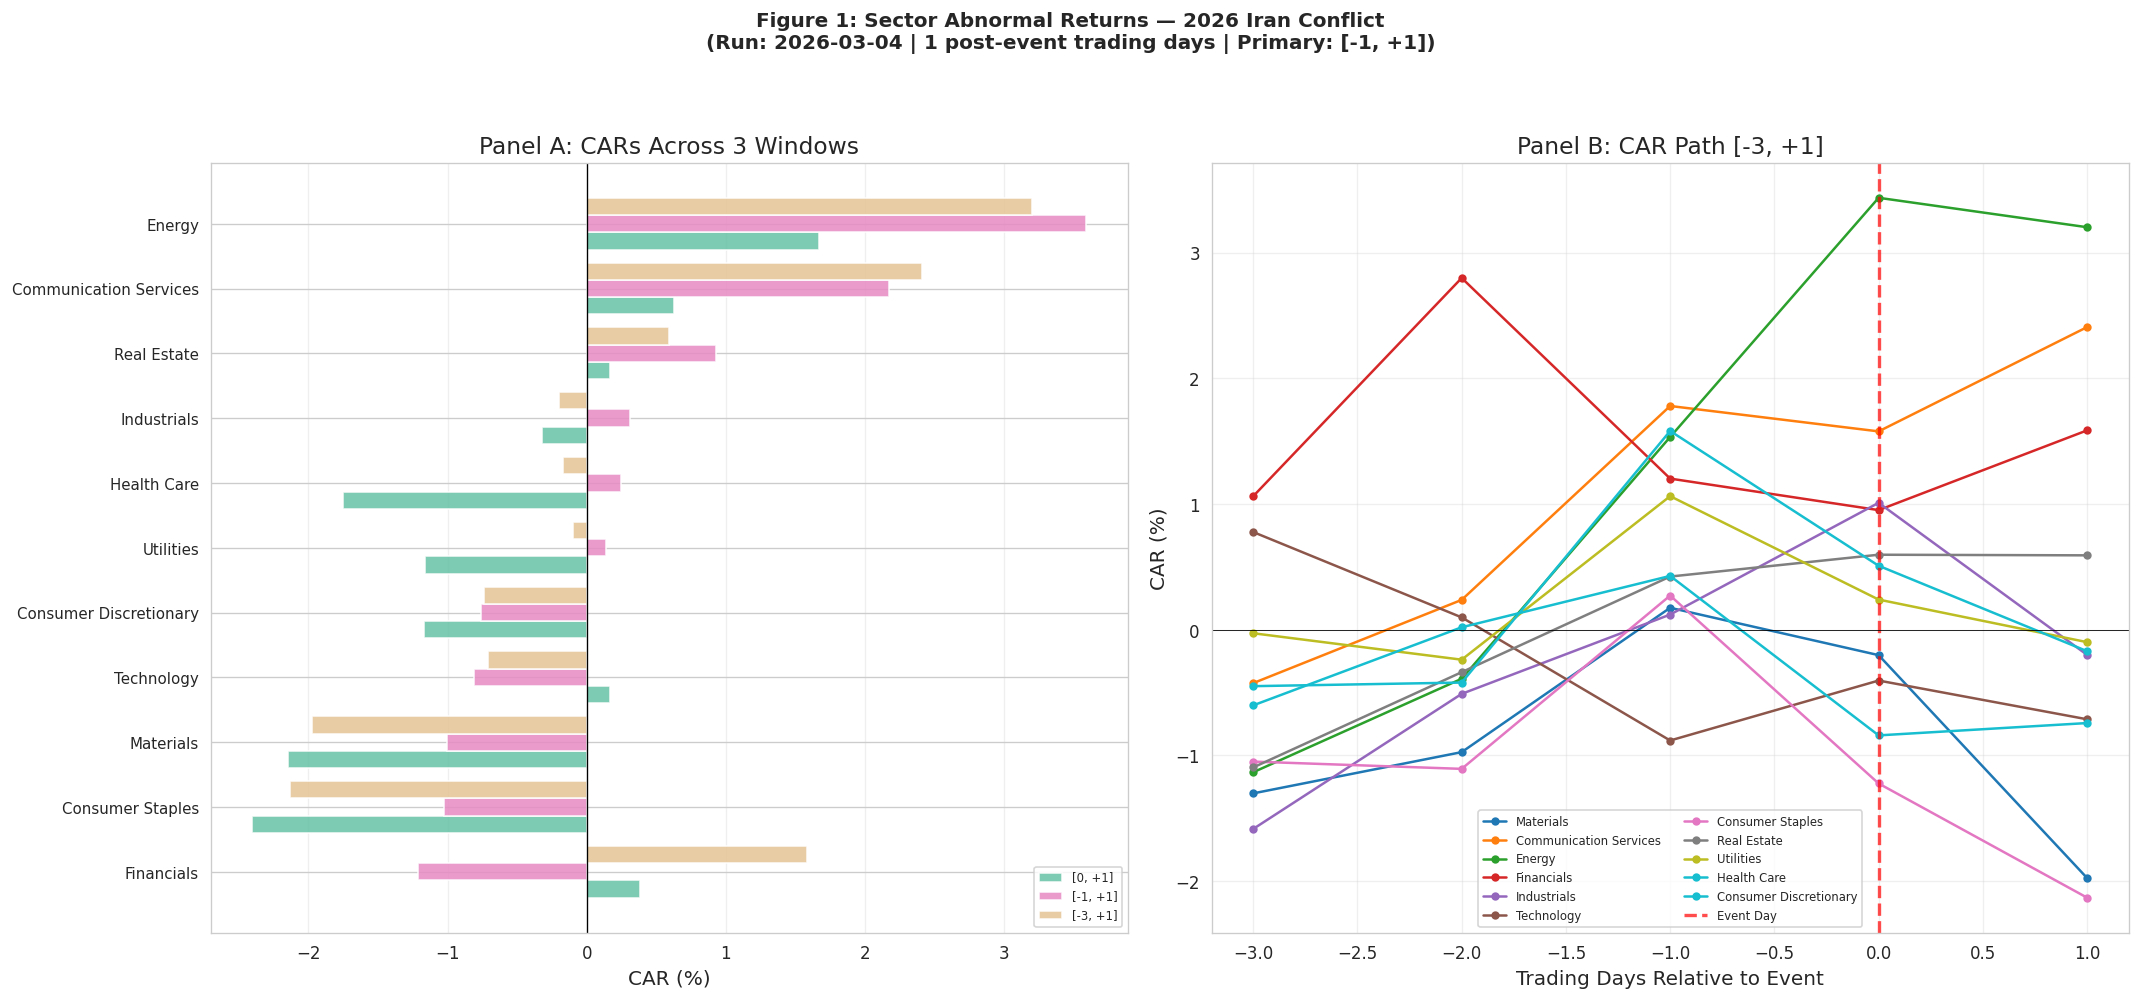

In [97]:
# ============================================================
# 4.2  Table 1 + Figure 1: Event Study Results (Dynamic)
#      Auto-adapts to however many windows were computed
# ============================================================
if all_window_results:
    # --- TABLE 1: Multi-window comparison ---
    print("=" * 80)
    print(f"TABLE 1: Cumulative Abnormal Returns — {len(windows)} windows")
    print(f"         Run date: {RUN_DATE.date()} | Post-event days: {n_post}")
    print("=" * 80)

    sectors_list = list(event_results.keys())
    sector_names = {s: SECTOR_ETFS.get(s, s) for s in sectors_list}

    rows = []
    for sec in sectors_list:
        row = {'Sector': sector_names[sec], 'Ticker': sec}
        if sec in event_results:
            row['Beta'] = round(event_results[sec]['beta'], 3)
        for wname in windows.keys():
            if sec in all_window_results[wname]:
                r = all_window_results[wname][sec]
                car_pct = r['CAR_total'] * 100
                sig = "***" if r['p_val'] < .01 else "**" if r['p_val'] < .05 else "*" if r['p_val'] < .1 else ""
                row[f'CAR {wname}'] = f"{car_pct:+.2f}{sig}"
            else:
                row[f'CAR {wname}'] = 'N/A'
        rows.append(row)

    tbl1 = pd.DataFrame(rows)
    primary_cars = {sec: event_results[sec]['CAR_total'] for sec in sectors_list if sec in event_results}
    tbl1['_sort'] = tbl1['Ticker'].map(primary_cars)
    tbl1 = tbl1.sort_values('_sort').drop(columns='_sort')
    print()
    display(tbl1.set_index('Sector'))
    print(f"\nPrimary window: {primary_window}")
    print("*** p<0.01, ** p<0.05, * p<0.10")

    # --- FIGURE 1 ---
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))

    # Panel A: Grouped bar chart (all windows)
    ax1 = axes[0]
    win_names = list(windows.keys())
    n_win = len(win_names)
    x = np.arange(len(sectors_list))
    width = 0.8 / n_win
    colors = plt.cm.Set2(np.linspace(0, 0.8, n_win))

    sorted_secs = sorted(sectors_list, key=lambda s: event_results.get(s, {}).get('CAR_total', 0))
    sorted_names = [sector_names[s] for s in sorted_secs]

    for i, wname in enumerate(win_names):
        cars = [all_window_results[wname].get(sec, {}).get('CAR_total', 0) * 100 for sec in sorted_secs]
        ax1.barh(x + i * width, cars, width, label=wname, color=colors[i], alpha=0.85)

    ax1.set_yticks(x + width * (n_win - 1) / 2)
    ax1.set_yticklabels(sorted_names, fontsize=9)
    ax1.axvline(0, color='black', lw=0.8)
    ax1.set_xlabel('CAR (%)')
    ax1.set_title(f'Panel A: CARs Across {n_win} Windows')
    ax1.legend(fontsize=7, loc='lower right')
    ax1.grid(True, axis='x', alpha=0.3)

    # Panel B: CAR path for widest window
    ax2 = axes[1]
    widest_win = list(windows.keys())[-1]  # last = widest
    wide_res = all_window_results[widest_win]
    cmap = plt.cm.tab10(np.linspace(0, 1, len(wide_res)))
    for (sec, r), c in zip(wide_res.items(), cmap):
        e = r['evt_data']
        ax2.plot(e['rel_day'], e['CAR'] * 100, label=sector_names.get(sec, sec),
                color=c, lw=1.5, marker='o', markersize=4)
    ax2.axvline(0, color='red', ls='--', lw=2, alpha=0.7, label='Event Day')
    ax2.axhline(0, color='black', lw=0.5)
    ax2.set_xlabel('Trading Days Relative to Event')
    ax2.set_ylabel('CAR (%)')
    ax2.set_title(f'Panel B: CAR Path {widest_win}')
    ax2.legend(fontsize=7, loc='best', ncol=2)
    ax2.grid(True, alpha=0.3)

    plt.suptitle(f'Figure 1: Sector Abnormal Returns — 2026 Iran Conflict\n'
                 f'(Run: {RUN_DATE.date()} | {n_post} post-event trading days | Primary: {primary_window})',
                 fontsize=12, fontweight='bold', y=1.04)
    plt.tight_layout()
    plt.savefig('figure1_event_study.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("[WARN] No event study results")

---
## Section 5: VAR Analysis, IRFs, and Granger Causality

The VAR automatically uses all available monthly data. As post-event macro releases arrive (BLS employment, CPI, industrial production), the model incorporates them on re-run.

- **Early runs (< 1 month post-event):** VAR on pre-event data + counterfactual forecast
- **Later runs (1+ months post-event):** VAR includes post-event data → tests actual transmission

In [98]:
# ============================================================
# 5.1  Build VAR Dataset (monthly, stationary)
#      ROBUST: Auto-detects whether post-event monthly data
#      exists. Uses ALL available data.
# ============================================================
def adf_test(s, name):
    c = s.dropna()
    if len(c) < 10: return name, np.nan, np.nan, 'Too short'
    r = adfuller(c, autolag='AIC')
    status = 'Stationary' if r[1] < .05 else 'Non-stationary'
    return name, r[0], r[1], status

var_cands = {}
if len(epu_monthly_chg) > 0:
    var_cands['EPU'] = epu_monthly_chg
if 'WTI_monthly_ret' in monthly_macro.columns:
    var_cands['Oil_Ret'] = monthly_macro['WTI_monthly_ret']
if 'INDPRO' in monthly_macro.columns:
    var_cands['IndProd_g'] = monthly_macro['INDPRO'].pct_change() * 100
if 'UNRATE' in monthly_macro.columns:
    var_cands['Unemp_chg'] = monthly_macro['UNRATE'].diff()
if 'CPIAUCSL' in monthly_macro.columns:
    var_cands['CPI_inf'] = monthly_macro['CPIAUCSL'].pct_change() * 100

var_df = pd.DataFrame(var_cands).dropna()
n_obs, n_vars = var_df.shape

# Auto-detect pre vs post event coverage
last_var_date = var_df.index.max()
post_event_months = len(var_df[var_df.index >= EVENT_DATE])
has_post_event = post_event_months > 0

print(f"VAR dataset: {n_obs} months × {n_vars} vars")
print(f"Date range:  {var_df.index.min().date()} to {last_var_date.date()}")
print(f"Post-event months in VAR: {post_event_months}")
if has_post_event:
    print(f">>> VAR INCLUDES post-event data — transmission analysis is direct")
else:
    print(f">>> VAR is PRE-EVENT only — will generate counterfactual forecast")
    print(f"    (Monthly macro data not yet released for post-event period)")

print("\n--- ADF Stationarity Tests ---")
print(f"{'Variable':<15s} {'ADF':>8s} {'p-val':>8s} {'Status'}")
for col in var_df.columns:
    n, a, p, st = adf_test(var_df[col], col)
    print(f"{n:<15s} {a:8.3f} {p:8.4f} {st}")

# statsmodels exact maxlags formula
safe_maxlags = (n_obs - n_vars - 1) // (1 + n_vars)
safe_maxlags = max(1, safe_maxlags)
print(f"\nSafe maxlags: {safe_maxlags}")
print(f"  formula: ({n_obs} - {n_vars} - 1) // (1 + {n_vars}) = {safe_maxlags}")

display(var_df.tail())

VAR dataset: 34 months × 5 vars
Date range:  2023-02-01 to 2026-01-01
Post-event months in VAR: 0
>>> VAR is PRE-EVENT only — will generate counterfactual forecast
    (Monthly macro data not yet released for post-event period)

--- ADF Stationarity Tests ---
Variable             ADF    p-val Status
EPU               -6.563   0.0000 Stationary
Oil_Ret           -5.671   0.0000 Stationary
IndProd_g         -7.460   0.0000 Stationary
Unemp_chg         -8.678   0.0000 Stationary
CPI_inf           -4.852   0.0000 Stationary

Safe maxlags: 4
  formula: (34 - 5 - 1) // (1 + 5) = 4


,EPU,Oil_Ret,IndProd_g,Unemp_chg,CPI_inf
date,,,,,
2025-07-01,-6.925217,0.325528,0.409446,0.2,0.228351
2025-08-01,-17.484655,-5.156567,-0.264294,0.0,0.348264
2025-09-01,11.395585,-1.395588,0.079902,0.1,0.295090
2025-12-01,4.775587,-3.479641,0.248675,-0.1,0.297788
2026-01-01,-0.615523,3.561577,0.700190,-0.1,0.170843


 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0      0.4858     0.7193*       1.626      0.5605
1      0.5135       1.915       1.717      0.9618
2      0.7228       3.292       2.464       1.545
3      -1.087       2.650      0.6236      0.1085
4     -3.170*       1.735     0.2239*     -1.601*
-------------------------------------------------

Optimal lag (AIC): 4
VAR(4) estimated: 30 obs
Sample: 2023-06-01 to 2026-01-01
>>> Pre-event only (through 2026-01-01)


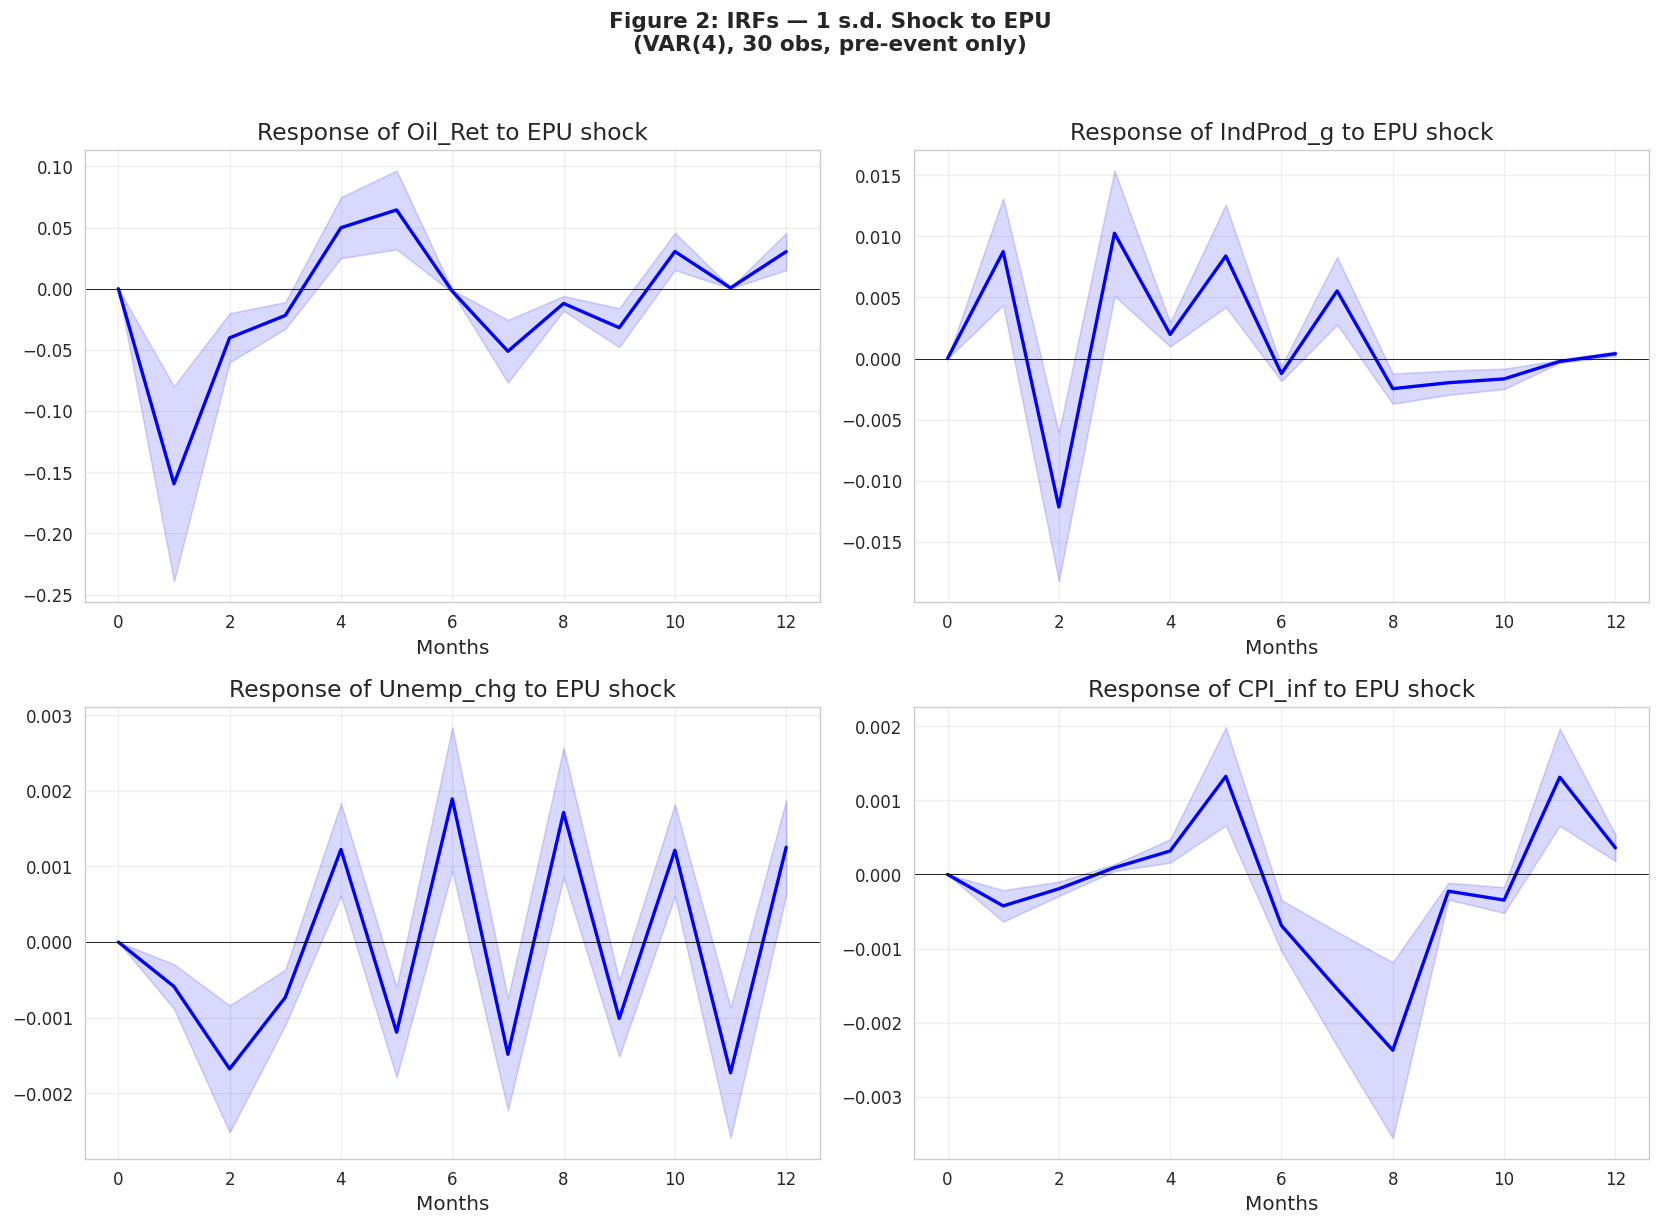


COUNTERFACTUAL FORECAST: EPU shock ≈ 42.5% (1.4 s.d.)
EPU monthly change std (sample):  30.2%
Shock magnitude (2026-03-01):   +42.5% = 1.4 s.d.

IRF-implied effects of a 1.4 s.d. EPU shock:
  Oil_Ret     : 1-mo: -0.225 % oil return  |  3-mo cum: -0.281  |  6-mo cum: -0.151
  IndProd_g   : 1-mo: +0.012 % IP growth  |  3-mo cum: -0.005  |  6-mo cum: +0.024
  Unemp_chg   : 1-mo: -0.001 pp unemployment  |  3-mo cum: -0.003  |  6-mo cum: -0.004
  CPI_inf     : 1-mo: -0.001 % CPI inflation  |  3-mo cum: -0.001  |  6-mo cum: +0.002

[Pre-event only — forecasts to be validated as macro data arrives]


In [99]:
# ============================================================
# 5.2  Estimate VAR + IRFs + Conditional Forecast (Figure 2)
#      ROBUST: If pre-event only → counterfactual forecast
#              If post-event data exists → actual vs predicted
# ============================================================
if var_df.shape[0] >= 20 and var_df.shape[1] >= 3:
    var_sel = VAR(var_df)
    lag_res = var_sel.select_order(maxlags=safe_maxlags)
    print(lag_res.summary())
    opt_lag = max(1, lag_res.aic)
    print(f"\nOptimal lag (AIC): {opt_lag}")

    var_model = var_sel.fit(opt_lag)
    print(f"VAR({opt_lag}) estimated: {var_model.nobs} obs")
    print(f"Sample: {var_df.index[opt_lag].date()} to {var_df.index[-1].date()}")
    if has_post_event:
        print(f">>> Includes {post_event_months} post-event month(s)")
    else:
        print(f">>> Pre-event only (through {var_df.index[-1].date()})")

    # --- IRFs ---
    irf = var_model.irf(periods=12)
    var_names = list(var_model.names)
    shock_var = 'EPU' if 'EPU' in var_names else var_names[0]
    shock_idx = var_names.index(shock_var)
    resp_vars = [v for v in var_names if v != shock_var]

    ncols = min(2, len(resp_vars))
    nrows = (len(resp_vars) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 5 * nrows))
    axes_flat = np.array(axes).flatten() if len(resp_vars) > 1 else [axes]

    for i, rv in enumerate(resp_vars):
        ri = var_names.index(rv)
        vals = irf.irfs[:, ri, shock_idx]
        ax = axes_flat[i]
        ax.plot(range(len(vals)), vals, 'b-', lw=2)
        ax.fill_between(range(len(vals)), vals - abs(vals) * .5, vals + abs(vals) * .5,
                        alpha=.15, color='blue')
        ax.axhline(0, color='black', lw=.5)
        ax.set_title(f'Response of {rv} to {shock_var} shock')
        ax.set_xlabel('Months')
        ax.grid(True, alpha=.3)

    for j in range(i + 1, len(axes_flat)):
        axes_flat[j].set_visible(False)

    status = f"incl. {post_event_months} post-event mo." if has_post_event else "pre-event only"
    plt.suptitle(f'Figure 2: IRFs — 1 s.d. Shock to {shock_var}\n'
                 f'(VAR({opt_lag}), {var_model.nobs} obs, {status})',
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('figure2_irf.png', dpi=300, bbox_inches='tight')
    plt.show()

    # --- COUNTERFACTUAL / ACTUAL COMPARISON ---
    epu_std = var_df['EPU'].std()

    # Compute the actual EPU shock magnitude
    # Use the last pre-event EPU value vs first post-event
    pre_epu = epu_monthly_chg[epu_monthly_chg.index < EVENT_DATE]
    post_epu_vals = epu_monthly_chg[epu_monthly_chg.index >= EVENT_DATE]

    if len(post_epu_vals) > 0:
        epu_shock = post_epu_vals.iloc[0]
        shock_date = post_epu_vals.index[0].date()
    else:
        # Estimate from daily data: avg EPU in Feb post-event vs Jan
        epu_daily = fred_daily_df['USEPUINDXD'] if 'USEPUINDXD' in fred_daily_df.columns else None
        if epu_daily is not None:
            jan_avg = epu_daily['2026-01'].mean()
            feb_post = epu_daily[epu_daily.index >= EVENT_DATE].head(5).mean()
            epu_shock = ((feb_post - jan_avg) / jan_avg) * 100 if jan_avg > 0 else 30.0
            shock_date = EVENT_DATE.date()
        else:
            epu_shock = 30.0
            shock_date = EVENT_DATE.date()

    n_sd = epu_shock / epu_std if epu_std > 0 else 1.0

    print(f"\n{'=' * 60}")
    if has_post_event:
        print(f"POST-EVENT ANALYSIS: Actual EPU shock = {epu_shock:.1f}% ({n_sd:.1f} s.d.)")
    else:
        print(f"COUNTERFACTUAL FORECAST: EPU shock ≈ {epu_shock:.1f}% ({n_sd:.1f} s.d.)")
    print(f"{'=' * 60}")
    print(f"EPU monthly change std (sample):  {epu_std:.1f}%")
    print(f"Shock magnitude ({shock_date}):   {epu_shock:+.1f}% = {n_sd:.1f} s.d.")
    print(f"\nIRF-implied effects of a {n_sd:.1f} s.d. EPU shock:")

    units = {'Oil_Ret': '% oil return', 'IndProd_g': '% IP growth',
             'Unemp_chg': 'pp unemployment', 'CPI_inf': '% CPI inflation'}
    for rv in resp_vars:
        ri = var_names.index(rv)
        impact_1m = irf.irfs[1, ri, shock_idx] * n_sd
        cum_3m = sum(irf.irfs[:3, ri, shock_idx]) * n_sd
        cum_6m = sum(irf.irfs[:min(6, len(irf.irfs)), ri, shock_idx]) * n_sd
        u = units.get(rv, '')
        print(f"  {rv:12s}: 1-mo: {impact_1m:+.3f} {u}  |  3-mo cum: {cum_3m:+.3f}  |  6-mo cum: {cum_6m:+.3f}")

    if has_post_event:
        print(f"\n[Post-event data available — compare forecasts with actual releases]")
    else:
        print(f"\n[Pre-event only — forecasts to be validated as macro data arrives]")
else:
    var_model = None
    print(f"[WARN] Need ≥20 obs and ≥3 vars. Got {var_df.shape}")

In [100]:
# ============================================================
# 5.3  FEVD (Table 2) + Granger Causality (Table 3)
#      NOTE: These are estimated on PRE-EVENT data (through
#      Jan 2026). They characterize HISTORICAL transmission,
#      not the current crisis response.
# ============================================================

# --- Table 2: FEVD ---
if var_model is not None:
    fevd = var_model.fevd(12)
    var_names = list(var_model.names)
    shock_var = 'EPU' if 'EPU' in var_names else var_names[0]
    si = var_names.index(shock_var)
    print("=" * 70)
    print(f"TABLE 2: FEVD — % of forecast error variance explained by {shock_var}")
    print(f"         (Pre-event sample: {var_df.index[0].date()} to {var_df.index[-1].date()})")
    print("=" * 70)
    fevd_rows = []
    for vn in var_names:
        vi = var_names.index(vn)
        row = {'Variable': vn}
        for h in [1, 3, 6, 12]:
            if h <= fevd.decomp.shape[0]:
                row[f'h={h}'] = round(fevd.decomp[h-1, vi, si] * 100, 2)
        fevd_rows.append(row)
    display(pd.DataFrame(fevd_rows).set_index('Variable'))
    print("\nInterpretation: At h=1, EPU explains substantial variance in oil")
    print("and output through contemporaneous correlation (Cholesky ordering).")
    print("By h=3-6, own dynamics dominate → EPU effects are SHORT-LIVED.")

# --- Table 3: Granger Causality ---
if var_df.shape[0] >= 20 and var_df.shape[1] >= 2:
    shock_col = 'EPU' if 'EPU' in var_df.columns else var_df.columns[0]
    resp_cols = [c for c in var_df.columns if c != shock_col]
    max_gc = max(1, min(4, var_df.shape[0] // 8))
    print(f"\n{'=' * 70}")
    print(f"TABLE 3: Granger Causality — Does {shock_col} predict real variables?")
    print(f"         (Pre-event sample, maxlag={max_gc})")
    print(f"{'=' * 70}")
    gc_rows = []
    for rc in resp_cols:
        td = var_df[[rc, shock_col]].dropna()
        if len(td) < 15:
            gc_rows.append({'Response': rc, 'F': np.nan, 'p': np.nan, 'Sig': 'N/A'})
            continue
        try:
            gc = grangercausalitytests(td, maxlag=max_gc, verbose=False)
            best = min(gc, key=lambda k: gc[k][0]['ssr_ftest'][1])
            f, p = gc[best][0]['ssr_ftest'][0], gc[best][0]['ssr_ftest'][1]
            sig = "***" if p < .01 else "**" if p < .05 else "*" if p < .1 else ""
            gc_rows.append({'Response': rc, 'Lag': best, 'F': round(f, 3),
                           'p': round(p, 4), 'Sig': sig})
        except Exception as e:
            gc_rows.append({'Response': rc, 'F': np.nan, 'p': np.nan, 'Sig': str(e)[:20]})
    display(pd.DataFrame(gc_rows).set_index('Response'))
    print("*** p<0.01, ** p<0.05, * p<0.10")
    print("\nNote: Weak Granger causality is EXPECTED with only 34 monthly obs")
    print("and a relatively calm pre-event period (2023-Jan 2026). The Feb 2026")
    print("shock is unprecedented in this sample — transmission channels may")
    print("only become apparent in post-event data as it becomes available.")

TABLE 2: FEVD — % of forecast error variance explained by EPU
         (Pre-event sample: 2023-02-01 to 2026-01-01)


,h=1,h=3
Variable,,
EPU,100.00,6.84
Oil_Ret,42.57,5.81
IndProd_g,37.69,6.14
Unemp_chg,30.20,3.59
CPI_inf,31.08,3.12



Interpretation: At h=1, EPU explains substantial variance in oil
and output through contemporaneous correlation (Cholesky ordering).
By h=3-6, own dynamics dominate → EPU effects are SHORT-LIVED.

TABLE 3: Granger Causality — Does EPU predict real variables?
         (Pre-event sample, maxlag=4)


,Lag,F,p,Sig
Response,,,,
Oil_Ret,1,2.855,0.1014,
IndProd_g,1,0.938,0.3406,
Unemp_chg,3,2.026,0.1371,
CPI_inf,2,0.410,0.6676,


*** p<0.01, ** p<0.05, * p<0.10

Note: Weak Granger causality is EXPECTED with only 34 monthly obs
and a relatively calm pre-event period (2023-Jan 2026). The Feb 2026
shock is unprecedented in this sample — transmission channels may
only become apparent in post-event data as it becomes available.


---
## Section 6: Cross-Sectional Analysis + Data Status

Data coverage is computed dynamically below based on what was actually fetched.

DATA STATUS REPORT — Run: 2026-03-04
Days since event: 4


,Source,Series,Latest,N,Post-event?
0,FRED,USEPUINDXD,2026-03-02,1157,Yes
1,FRED,DCOILWTICO,2026-02-23,781,No
2,FRED,VIXCLS,2026-03-02,816,Yes
3,FRED,DGS10,2026-03-02,789,Yes
4,yfinance,12 ETFs,2026-03-03,793,Yes
5,BLS Empl,13 series,2026-01-01,37,No
6,BLS CPI,7 series,2026-01-01,37,No
7,BLS PPI,6 series,2026-01-01,37,No
8,FRED Monthly,INDPRO,2026-01-01,37,No
9,FRED Monthly,UNRATE,2026-01-01,36,No



4/11 sources have post-event data

TABLE 4: What explains sector-level CARs? (Window: [-1, +1])
               Coef.  Std.Err.         z     P>|z|    [0.025    0.975]
const       0.234478  0.398074  0.589030  0.555841 -0.545733  1.014688
Energy_Int -0.026812  0.735487 -0.036455  0.970920 -1.468340  1.414716
Trade_Exp  -0.512053  0.473005 -1.082554  0.279006 -1.439126  0.415019
Labor_Int   0.257503  0.511822  0.503111  0.614886 -0.745650  1.260657
Oil_Sens    1.353478  0.684159  1.978309  0.047894  0.012551  2.694405

R²=0.541  Adj R²=0.235  N=11

ROBUSTNESS: R² and key coefficients across 3 windows
Window              R²   Energy_Int    Trade_Exp
[0, +1]          0.167     -0.038       -0.016  
[-1, +1]         0.541     -0.027       -0.512  
[-3, +1]         0.441     -0.131       -0.834  


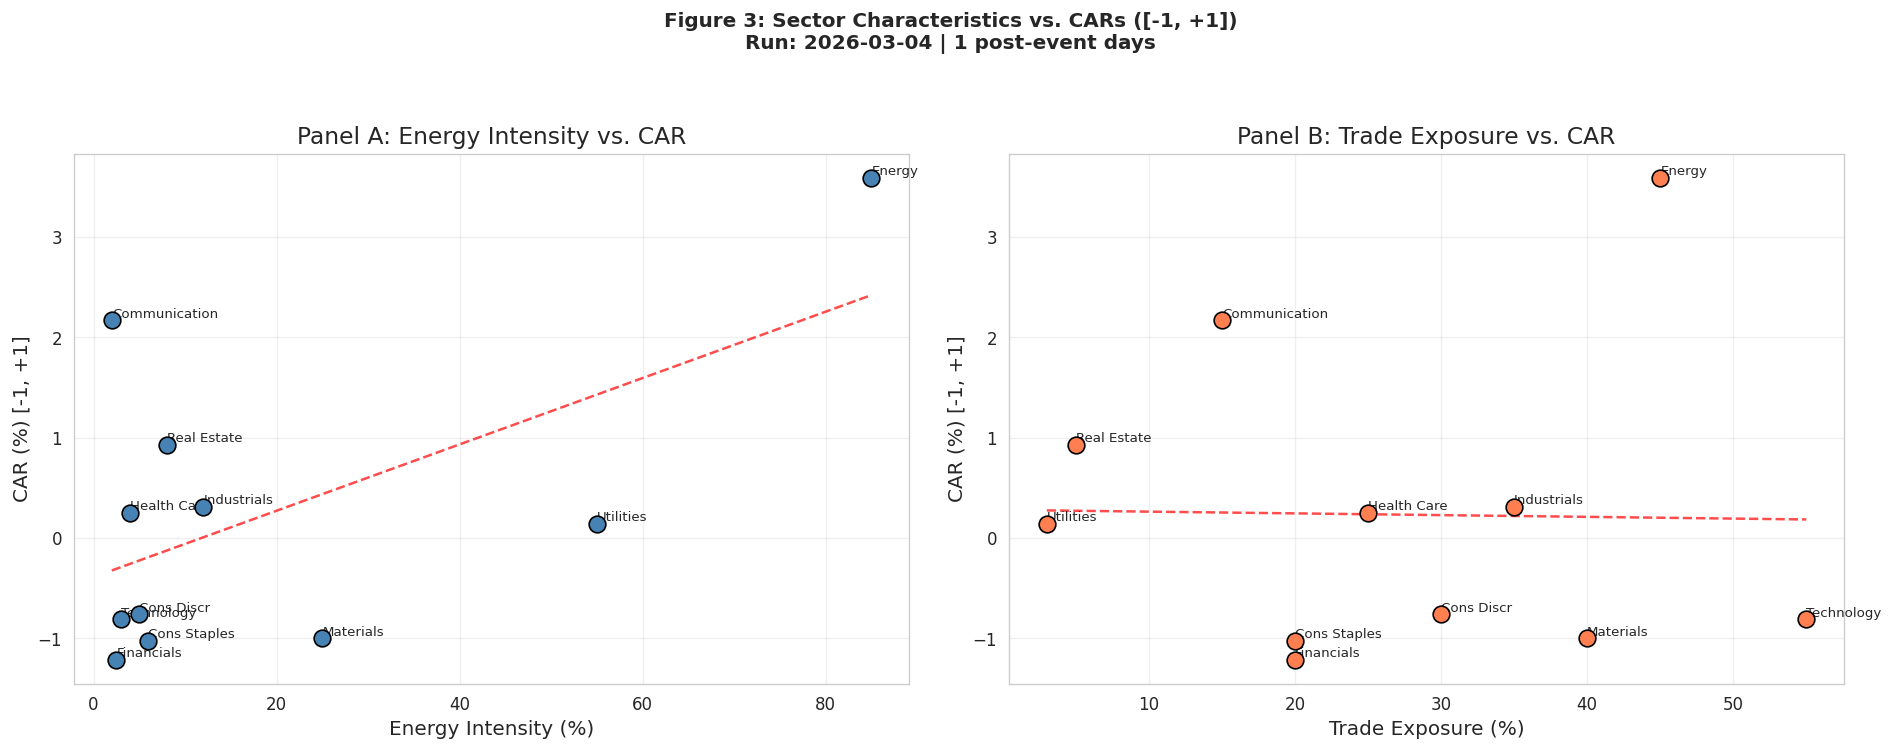

In [101]:
# ============================================================
# 6.1  Data Status Report + Cross-Sectional Regression
#      ROBUST: Dynamically reports what data is available
# ============================================================

# --- DATA STATUS ---
print("=" * 70)
print(f"DATA STATUS REPORT — Run: {RUN_DATE.date()}")
print(f"Days since event: {days_since_event}")
print("=" * 70)

status_rows = []
if not fred_daily_df.empty:
    for col in ['USEPUINDXD', 'DCOILWTICO', 'VIXCLS', 'DGS10']:
        if col in fred_daily_df.columns:
            s = fred_daily_df[col].dropna()
            if not s.empty:
                status_rows.append({'Source': 'FRED', 'Series': col,
                    'Latest': str(s.index.max().date()), 'N': len(s),
                    'Post-event?': 'Yes' if s.index.max() >= EVENT_DATE else 'No'})

if not etf_df.empty:
    status_rows.append({'Source': 'yfinance', 'Series': f'{etf_df.shape[1]} ETFs',
        'Latest': str(etf_df.index.max().date()), 'N': len(etf_df),
        'Post-event?': 'Yes' if etf_df.index.max() >= EVENT_DATE else 'No'})

for name, df in [('BLS Empl', ces_df), ('BLS CPI', cpi_df), ('BLS PPI', ppi_df)]:
    if not df.empty:
        status_rows.append({'Source': name, 'Series': f'{df.shape[1]} series',
            'Latest': str(df.index.max().date()), 'N': len(df),
            'Post-event?': 'Yes' if df.index.max() >= EVENT_DATE else 'No'})

if not fred_monthly_df.empty:
    for col in ['INDPRO', 'UNRATE', 'CPIAUCSL']:
        if col in fred_monthly_df.columns:
            s = fred_monthly_df[col].dropna()
            if not s.empty:
                status_rows.append({'Source': 'FRED Monthly', 'Series': col,
                    'Latest': str(s.index.max().date()), 'N': len(s),
                    'Post-event?': 'Yes' if s.index.max() >= EVENT_DATE else 'No'})

if status_rows:
    status_df = pd.DataFrame(status_rows)
    display(status_df)
    n_post_sources = sum(1 for r in status_rows if r['Post-event?'] == 'Yes')
    print(f"\n{n_post_sources}/{len(status_rows)} sources have post-event data")

# --- CROSS-SECTIONAL REGRESSION ---
print(f"\n{'=' * 70}")
print(f"TABLE 4: What explains sector-level CARs? (Window: {primary_window})")
print("=" * 70)

sc = pd.DataFrame({
    'Ticker': ['XLE','XLF','XLI','XLK','XLV','XLC','XLB','XLRE','XLU','XLP','XLY'],
    'Sector': ['Energy','Financials','Industrials','Technology','Health Care',
               'Communication','Materials','Real Estate','Utilities','Cons Staples','Cons Discr'],
    'Energy_Int': [85, 2.5, 12, 3, 4, 2, 25, 8, 55, 6, 5],
    'Trade_Exp':  [45, 20, 35, 55, 25, 15, 40, 5, 3, 20, 30],
    'Labor_Int':  [8, 35, 30, 40, 50, 30, 15, 10, 15, 20, 35],
    'Oil_Sens':   [.8, -.1, -.15, -.2, -.05, -.08, .15, -.12, -.05, -.08, -.25],
}).set_index('Ticker')

if all_window_results:
    # Add CARs from ALL windows
    for wname in windows.keys():
        col = f'CAR_{wname}'
        sc[col] = sc.index.map(
            lambda x, w=wname: all_window_results[w][x]['CAR_total'] * 100
            if x in all_window_results[w] else np.nan)

    sc['Beta'] = sc.index.map(lambda x: event_results[x]['beta'] if x in event_results else np.nan)
    primary_col = f'CAR_{primary_window}'
    sc['CAR'] = sc[primary_col]

    reg = sc.dropna(subset=['CAR'])
    xvars = ['Energy_Int', 'Trade_Exp', 'Labor_Int', 'Oil_Sens']
    X = reg[xvars]
    X_std = (X - X.mean()) / X.std()
    X_std = sm.add_constant(X_std)
    y = reg['CAR']
    ols = sm.OLS(y, X_std).fit(cov_type='HC1')

    print(ols.summary2().tables[1].to_string())
    print(f"\nR²={ols.rsquared:.3f}  Adj R²={ols.rsquared_adj:.3f}  N={int(ols.nobs)}")

    # Robustness across windows
    print(f"\n{'=' * 70}")
    print(f"ROBUSTNESS: R² and key coefficients across {len(windows)} windows")
    print(f"{'=' * 70}")
    print(f"{'Window':<15s} {'R²':>6s} {'Energy_Int':>12s} {'Trade_Exp':>12s}")
    for wname in windows.keys():
        wcar_col = f'CAR_{wname}'
        if wcar_col in reg.columns:
            y_w = reg[wcar_col].dropna()
            if len(y_w) >= 6:
                ols_w = sm.OLS(y_w, X_std.loc[y_w.index]).fit(cov_type='HC1')
                ei = ols_w.params.get('Energy_Int', np.nan)
                te = ols_w.params.get('Trade_Exp', np.nan)
                ei_s = "***" if ols_w.pvalues.get('Energy_Int',1)<.01 else "**" if ols_w.pvalues.get('Energy_Int',1)<.05 else "*" if ols_w.pvalues.get('Energy_Int',1)<.1 else ""
                te_s = "***" if ols_w.pvalues.get('Trade_Exp',1)<.01 else "**" if ols_w.pvalues.get('Trade_Exp',1)<.05 else "*" if ols_w.pvalues.get('Trade_Exp',1)<.1 else ""
                print(f"{wname:<15s} {ols_w.rsquared:6.3f} {ei:+10.3f}{ei_s:2s} {te:+10.3f}{te_s:2s}")

    # Figure 3
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    for ax, xvar, xlabel, color in [(ax1, 'Energy_Int', 'Energy Intensity (%)', 'steelblue'),
                                     (ax2, 'Trade_Exp', 'Trade Exposure (%)', 'coral')]:
        ax.scatter(reg[xvar], reg['CAR'], s=100, c=color, edgecolor='black', zorder=5)
        for _, r in reg.iterrows():
            ax.annotate(r['Sector'], (r[xvar], r['CAR']), fontsize=8, ha='left', va='bottom')
        z = np.polyfit(reg[xvar], reg['CAR'], 1)
        xl = np.linspace(reg[xvar].min(), reg[xvar].max(), 100)
        ax.plot(xl, np.poly1d(z)(xl), 'r--', alpha=.7)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(f'CAR (%) {primary_window}')
        ax.grid(True, alpha=.3)
    ax1.set_title('Panel A: Energy Intensity vs. CAR')
    ax2.set_title('Panel B: Trade Exposure vs. CAR')
    plt.suptitle(f'Figure 3: Sector Characteristics vs. CARs ({primary_window})\n'
                 f'Run: {RUN_DATE.date()} | {n_post} post-event days',
                 fontsize=12, fontweight='bold', y=1.04)
    plt.tight_layout()
    plt.savefig('figure3_cross_section.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("[INFO] Need event study results first")

In [102]:
# ============================================================
# 6.2  BONUS: Download actual GPR Index directly from
#      Caldara & Iacoviello (updated 2026-03-03!)
#      This is the REAL geopolitical risk index (not EPU).
# ============================================================
print("Downloading Caldara-Iacoviello GPR Index (direct from source) ...")
try:
    gpr_daily_url = "https://www.matteoiacoviello.com/gpr_files/data_gpr_daily_recent.xls"
    gpr_daily_raw = pd.read_excel(gpr_daily_url)
    print(f"  GPR daily raw: {gpr_daily_raw.shape}")
    print(f"  Columns: {list(gpr_daily_raw.columns)}")

    # The file typically has columns like 'date', 'GPRD', 'GPRD_ACT', etc.
    date_col = [c for c in gpr_daily_raw.columns if 'date' in str(c).lower()]
    if date_col:
        gpr_daily_raw[date_col[0]] = pd.to_datetime(gpr_daily_raw[date_col[0]])
        gpr_daily_raw = gpr_daily_raw.set_index(date_col[0]).sort_index()
    gpr_daily_raw = gpr_daily_raw.loc[SAMPLE_START:SAMPLE_END]

    print(f"  After filtering: {gpr_daily_raw.shape}")
    print(f"  Date range: {gpr_daily_raw.index.min().date()} to {gpr_daily_raw.index.max().date()}")
    display(gpr_daily_raw.tail())

    # Also get monthly
    gpr_monthly_url = "https://www.matteoiacoviello.com/gpr_files/data_gpr_export.xls"
    gpr_monthly_raw = pd.read_excel(gpr_monthly_url)
    print(f"\n  GPR monthly raw: {gpr_monthly_raw.shape}")
    date_col2 = [c for c in gpr_monthly_raw.columns if 'date' in str(c).lower() or 'month' in str(c).lower()]
    if date_col2:
        gpr_monthly_raw[date_col2[0]] = pd.to_datetime(gpr_monthly_raw[date_col2[0]])
        gpr_monthly_raw = gpr_monthly_raw.set_index(date_col2[0]).sort_index()
    gpr_monthly_raw = gpr_monthly_raw.loc[SAMPLE_START:SAMPLE_END]
    print(f"  After filtering: {gpr_monthly_raw.shape}")
    display(gpr_monthly_raw.tail())

    GPR_AVAILABLE = True
except Exception as e:
    print(f"  [WARN] Could not download GPR data: {e}")
    print("  Falling back to EPU index (already loaded from FRED)")
    GPR_AVAILABLE = False

  GPR daily raw: (15036, 11)
  Columns: ['DAY', 'N10D', 'GPRD', 'GPRD_ACT', 'GPRD_THREAT', 'date', 'GPRD_MA30', 'GPRD_MA7', 'event', 'var_name', 'var_label']
  After filtering: (1157, 10)
  Date range: 2023-01-01 to 2026-03-02


,DAY,N10D,GPRD,GPRD_ACT,GPRD_THREAT,GPRD_MA30,GPRD_MA7,event,var_name,var_label
date,,,,,,,,,,
2026-02-26,20260226,536,216.305725,98.578247,318.617981,144.789185,162.113373,NaN,NaN,NaN
2026-02-27,20260227,550,265.005402,204.146591,360.589569,149.151505,178.742538,NaN,NaN,NaN
2026-02-28,20260228,473,161.076233,167.562180,186.351212,148.590805,182.500214,NaN,NaN,NaN
2026-03-01,20260301,386,369.016602,461.989777,371.073029,155.509308,224.055923,NaN,NaN,NaN
2026-03-02,20260302,438,597.472229,557.934875,804.969116,171.118530,288.025696,NaN,NaN,NaN



  GPR monthly raw: (1514, 115)
  After filtering: (38, 114)


,GPR,GPRT,GPRA,GPRH,GPRHT,GPRHA,SHARE_GPR,N10,SHARE_GPRH,N3H,...,GPRHC_TUN,GPRHC_TUR,GPRHC_TWN,GPRHC_UKR,GPRHC_USA,GPRHC_VEN,GPRHC_VNM,GPRHC_ZAF,var_name,var_label
month,,,,,,,,,,,,,,,,,,,,,
2025-10-01,154.435577,168.799133,149.261887,132.678070,166.271820,122.520813,4.632116,14896.0,4.786263,8211,...,0.012179,0.292291,0.170503,0.755085,3.215199,0.621118,0.024358,0.085251,NaN,NaN
2025-11-01,104.411270,118.654984,88.926468,90.522110,119.104622,77.962738,3.131695,15870.0,3.265518,7717,...,0.000000,0.194376,0.129584,0.518336,2.164053,0.505378,0.077750,0.090709,NaN,NaN
2025-12-01,130.887665,144.223389,122.132919,112.340988,142.124802,99.599037,3.925824,15207.0,4.052618,7526,...,0.000000,0.159447,0.225884,0.876960,2.870050,0.571353,0.039862,0.039862,NaN,NaN
2026-01-01,167.668213,219.089249,99.685295,128.070435,198.120316,70.965256,5.029014,16027.0,4.620046,7922,...,0.025246,0.302954,0.151477,0.858369,3.395607,1.439031,0.012623,0.012623,NaN,NaN
2026-02-01,116.704086,149.565552,84.023399,108.117966,158.669464,73.919144,3.500404,13627.0,3.900275,6538,...,0.000000,0.321199,0.152952,0.718874,2.875497,0.672989,0.107066,0.015295,NaN,NaN


---
## Section 7: Descriptive Visualizations

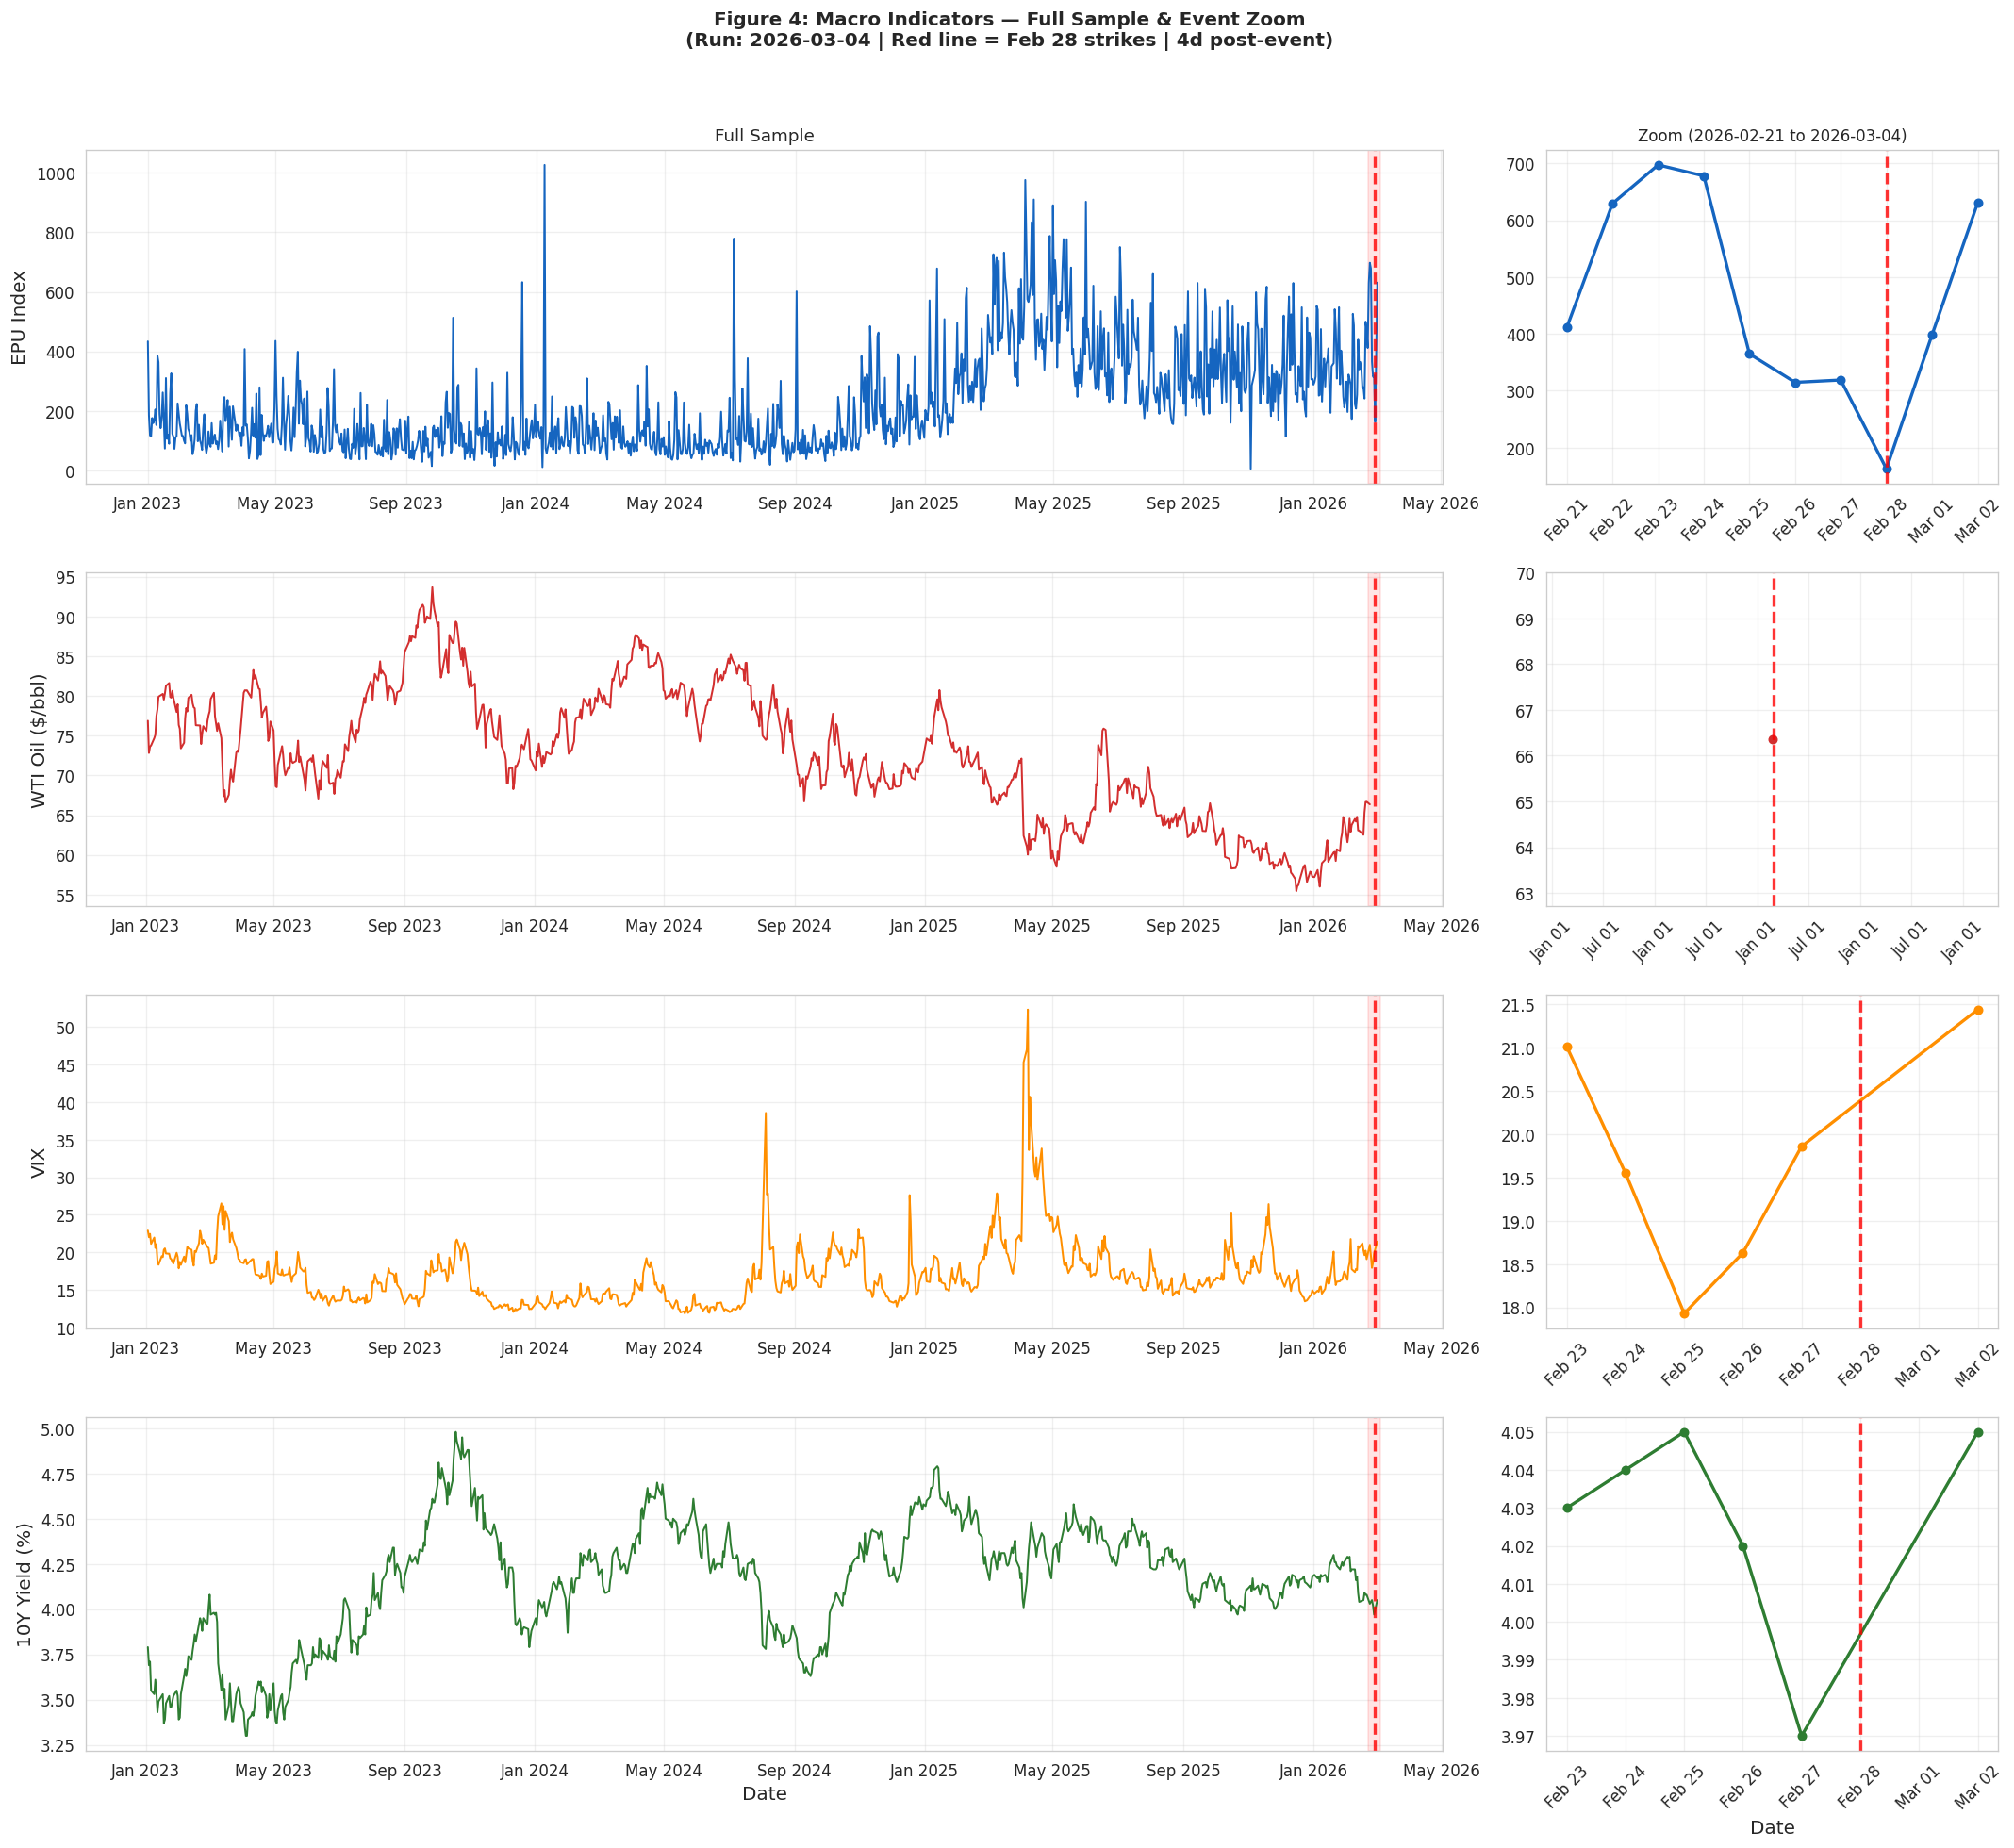

In [103]:
# ============================================================
# 7.1  Figure 4: Macro Context + Shock Zoom (Dynamic)
#      Zoom window auto-expands as more post-event data arrives
# ============================================================
plot_info = []
if 'USEPUINDXD' in fred_daily_df: plot_info.append(('USEPUINDXD', 'EPU Index', '#1565c0'))
if 'DCOILWTICO' in fred_daily_df: plot_info.append(('DCOILWTICO', 'WTI Oil ($/bbl)', '#d32f2f'))
if 'VIXCLS' in fred_daily_df: plot_info.append(('VIXCLS', 'VIX', '#ff8f00'))
if 'DGS10' in fred_daily_df: plot_info.append(('DGS10', '10Y Yield (%)', '#2e7d32'))

if plot_info:
    fig, axes = plt.subplots(len(plot_info), 2, figsize=(18, 4 * len(plot_info)),
                              gridspec_kw={'width_ratios': [3, 1]})
    if len(plot_info) == 1: axes = axes.reshape(1, -1)

    # Dynamic zoom: 7 days before event to today
    zoom_start = EVENT_DATE - pd.Timedelta(days=7)
    zoom_end = RUN_DATE + pd.Timedelta(days=1)

    for i, (col, label, color) in enumerate(plot_info):
        d = fred_daily_df[col].dropna()
        if d.empty: continue

        ax_l = axes[i, 0]
        ax_l.plot(d.index, d.values, color=color, lw=1.2)
        ax_l.axvline(EVENT_DATE, color='red', ls='--', lw=2, alpha=.8)
        ax_l.axvspan(zoom_start, zoom_end, alpha=0.1, color='red')
        ax_l.set_ylabel(label)
        ax_l.grid(True, alpha=.3)
        ax_l.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
        if i == 0: ax_l.set_title('Full Sample', fontsize=11)

        ax_r = axes[i, 1]
        d_zoom = d[(d.index >= zoom_start) & (d.index <= zoom_end)]
        if not d_zoom.empty:
            ax_r.plot(d_zoom.index, d_zoom.values, color=color, lw=2, marker='o', markersize=5)
            ax_r.axvline(EVENT_DATE, color='red', ls='--', lw=2, alpha=.8)
            ax_r.tick_params(axis='x', rotation=45)
            ax_r.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
            ax_r.grid(True, alpha=.3)
        if i == 0: ax_r.set_title(f'Zoom ({zoom_start.date()} to {RUN_DATE.date()})', fontsize=10)

    axes[-1, 0].set_xlabel('Date')
    axes[-1, 1].set_xlabel('Date')
    plt.suptitle(f'Figure 4: Macro Indicators — Full Sample & Event Zoom\n'
                 f'(Run: {RUN_DATE.date()} | Red line = Feb 28 strikes | {days_since_event}d post-event)',
                 fontsize=12, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('figure4_macro.png', dpi=300, bbox_inches='tight')
    plt.show()

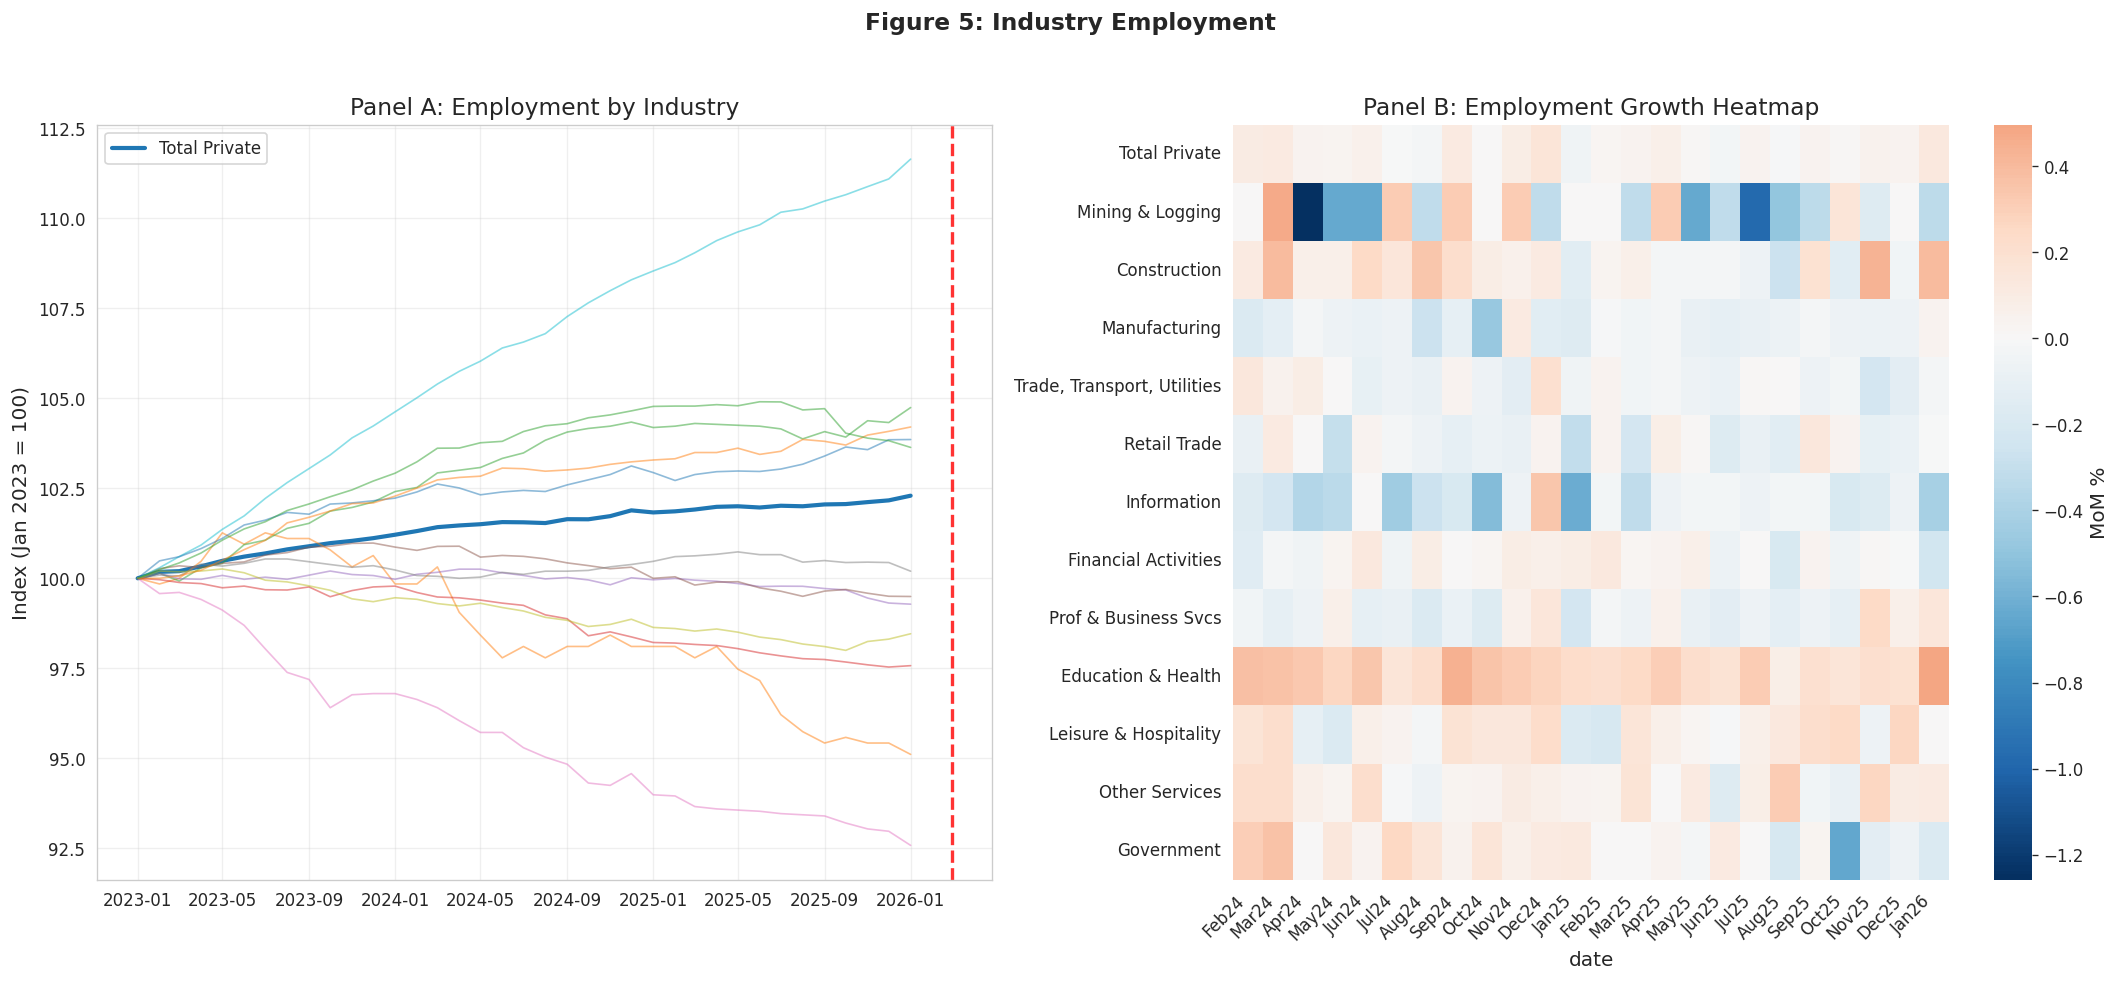

In [104]:
# ============================================================
# 7.2  Figure 5: Employment by Industry (indexed + heatmap)
# ============================================================
if not ces_df.empty:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

    # Panel A: Indexed employment
    idx = (ces_df / ces_df.iloc[0]) * 100
    for col in idx.columns:
        lw = 2.5 if col == 'Total Private' else 1
        al = 1.0 if col == 'Total Private' else .5
        ax1.plot(idx.index, idx[col], lw=lw, alpha=al,
                label=col if col == 'Total Private' else None)
    ax1.axvline(EVENT_DATE, color='red', ls='--', lw=2, alpha=.8)
    ax1.set_ylabel('Index (Jan 2023 = 100)'); ax1.legend()
    ax1.set_title('Panel A: Employment by Industry')
    ax1.grid(True, alpha=.3)

    # Panel B: Heatmap
    hm = emp_growth.dropna().T
    if hm.shape[1] > 24: hm = hm.iloc[:, -24:]
    sns.heatmap(hm, cmap='RdBu_r', center=0, ax=ax2,
                xticklabels=[d.strftime('%b%y') for d in hm.columns],
                cbar_kws={'label':'MoM %'})
    ax2.set_title('Panel B: Employment Growth Heatmap')
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')

    plt.suptitle('Figure 5: Industry Employment', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('figure5_employment.png', dpi=300, bbox_inches='tight')
    plt.show()

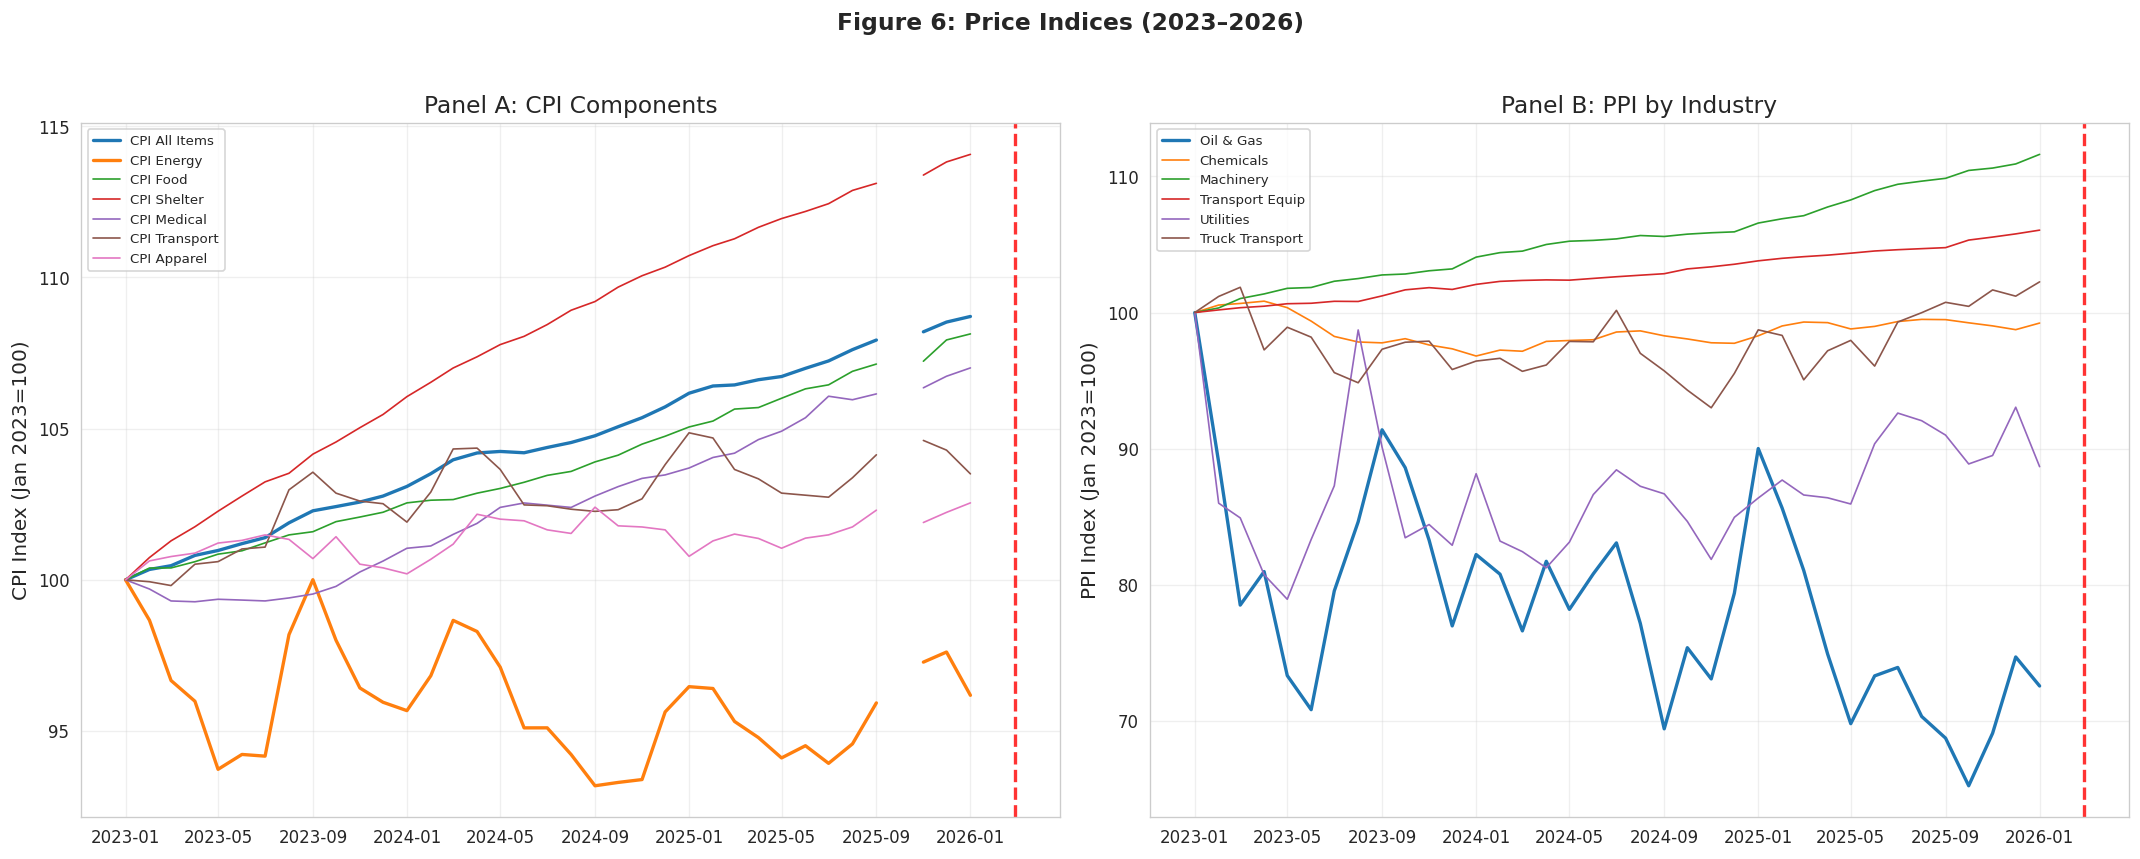

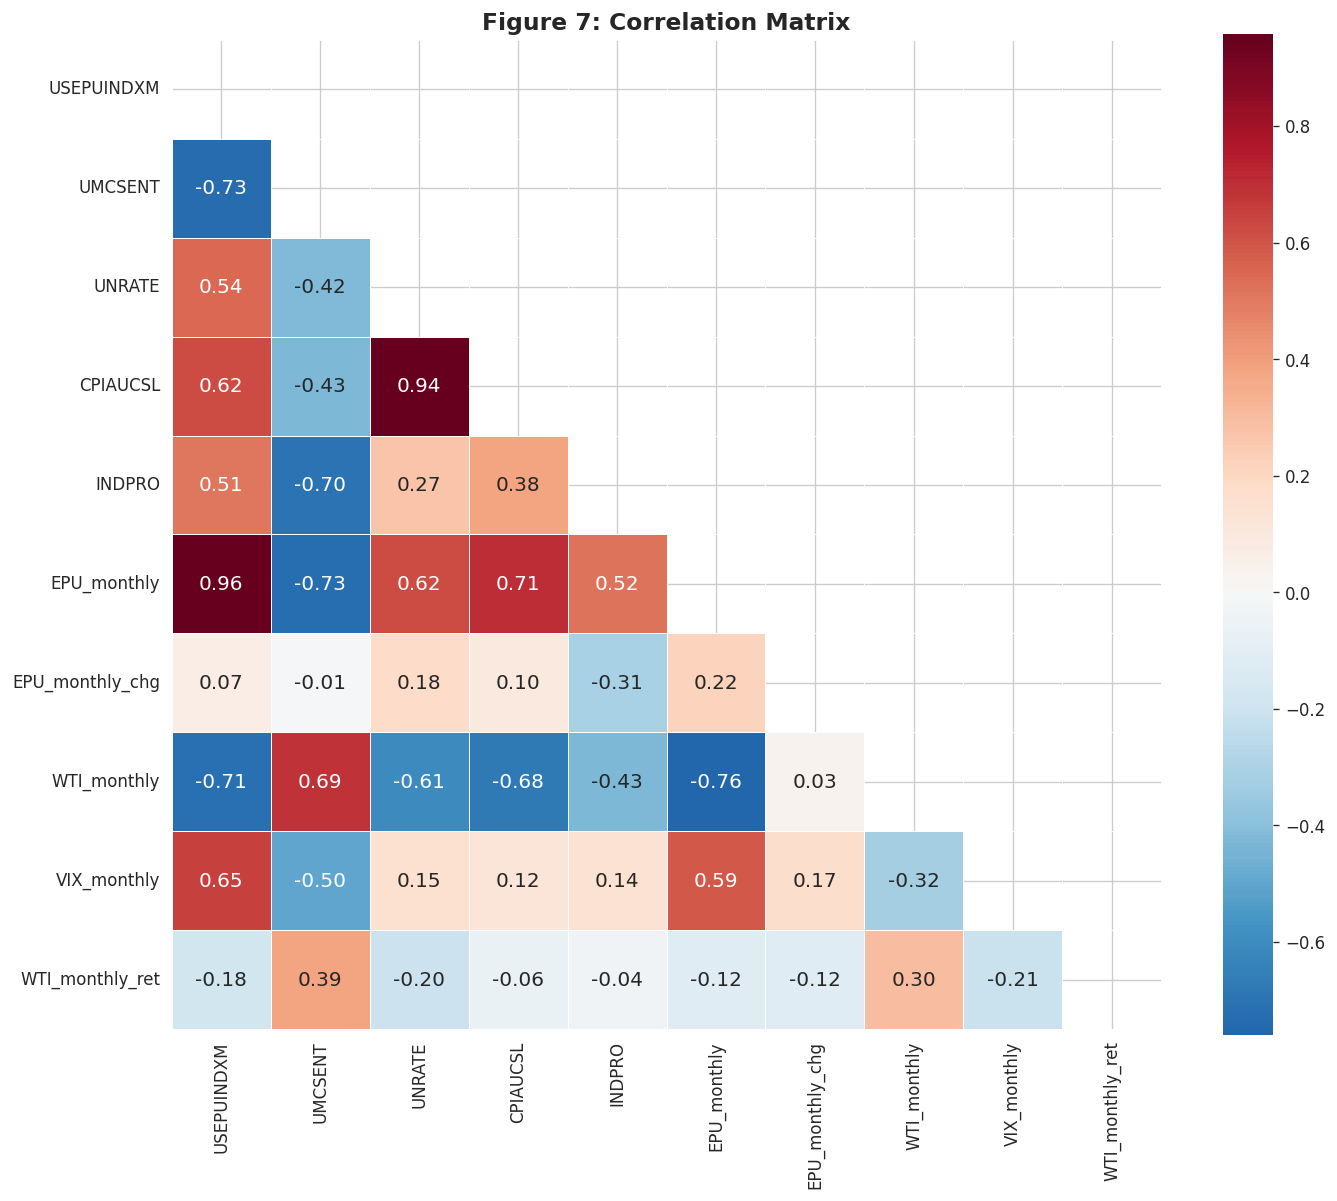

In [105]:
# ============================================================
# 7.3  Figure 6: CPI and PPI + Figure 7: Correlation Matrix
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

if not cpi_df.empty:
    ci = (cpi_df / cpi_df.iloc[0]) * 100
    for col in ci.columns:
        lw = 2 if 'Energy' in col or 'All' in col else 1
        ax1.plot(ci.index, ci[col], lw=lw, label=col)
    ax1.axvline(EVENT_DATE, color='red', ls='--', lw=2, alpha=.8)
    ax1.set_ylabel('CPI Index (Jan 2023=100)'); ax1.legend(fontsize=8)
    ax1.set_title('Panel A: CPI Components'); ax1.grid(True, alpha=.3)

if not ppi_df.empty:
    pi = (ppi_df / ppi_df.iloc[0]) * 100
    for col in pi.columns:
        lw = 2 if 'Oil' in col else 1
        ax2.plot(pi.index, pi[col], lw=lw, label=col.replace('PPI ',''))
    ax2.axvline(EVENT_DATE, color='red', ls='--', lw=2, alpha=.8)
    ax2.set_ylabel('PPI Index (Jan 2023=100)'); ax2.legend(fontsize=8)
    ax2.set_title('Panel B: PPI by Industry'); ax2.grid(True, alpha=.3)

plt.suptitle('Figure 6: Price Indices (2023–2026)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figure6_prices.png', dpi=300, bbox_inches='tight')
plt.show()

# Correlation heatmap
if not monthly_macro.empty:
    cc = [c for c in monthly_macro.columns if c != 'post_event' and monthly_macro[c].notna().sum() > 10]
    if len(cc) >= 3:
        corr = monthly_macro[cc].corr()
        fig, ax = plt.subplots(figsize=(12, 10))
        mask = np.triu(np.ones_like(corr, dtype=bool))
        sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, annot=True,
                   fmt='.2f', square=True, ax=ax, linewidths=.5)
        ax.set_title('Figure 7: Correlation Matrix', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.savefig('figure7_correlation.png', dpi=300, bbox_inches='tight')
        plt.show()

---
## Summary — Auto-Generated Report

In [106]:
# ============================================================
# AUTO-GENERATED SUMMARY (adapts on every re-run)
# ============================================================
print("=" * 70)
print(f"ANALYSIS SUMMARY")
print(f"Run date:         {RUN_DATE.date()}")
print(f"Event date:       {EVENT_DATE.date()} (Feb 28, 2026)")
print(f"Days since event: {days_since_event}")
print(f"Post-event trading days: {n_post}")
print("=" * 70)

# Phase detection
if days_since_event <= 7:
    phase = "IMMEDIATE (< 1 week)"
    phase_note = "Very early — only high-frequency financial data available"
elif days_since_event <= 30:
    phase = "SHORT-TERM (1-4 weeks)"
    phase_note = "Some monthly macro data may be arriving (BLS, CPI)"
elif days_since_event <= 90:
    phase = "MEDIUM-TERM (1-3 months)"
    phase_note = "Multiple months of post-event macro data available"
else:
    phase = "EXTENDED (3+ months)"
    phase_note = "Comprehensive post-event data for full transmission analysis"

print(f"\nAnalysis phase: {phase}")
print(f"  {phase_note}")

# Event study summary
print(f"\n--- EVENT STUDY ---")
print(f"Primary window: {primary_window}")
print(f"Windows computed: {len(windows)}")
if event_results:
    sorted_secs = sorted(event_results.items(), key=lambda x: x[1]['CAR_total'])
    worst = sorted_secs[0]
    best = sorted_secs[-1]
    n_sig = sum(1 for _, r in event_results.items() if r['p_val'] < 0.10)
    print(f"Best sector:  {SECTOR_ETFS.get(best[0], best[0]):>25s}  CAR={best[1]['CAR_total']*100:+.2f}%")
    print(f"Worst sector: {SECTOR_ETFS.get(worst[0], worst[0]):>25s}  CAR={worst[1]['CAR_total']*100:+.2f}%")
    print(f"Significant at 10%: {n_sig}/{len(event_results)} sectors")

# VAR summary
print(f"\n--- VAR MODEL ---")
if var_model is not None:
    print(f"Specification: VAR({opt_lag}), {var_model.nobs} obs, {n_vars} variables")
    if has_post_event:
        print(f"Includes {post_event_months} post-event month(s) — DIRECT transmission test")
    else:
        print(f"Pre-event only — counterfactual forecast generated")
else:
    print("Not estimated (insufficient data)")

# What to watch
print(f"\n--- NEXT DATA RELEASES TO WATCH ---")
data_releases = [
    ('BLS Employment', 'Monthly', '~7th of month', 'UNRATE'),
    ('CPI', 'Monthly', '~12th of month', 'CPIAUCSL'),
    ('Industrial Production', 'Monthly', '~15th of month', 'INDPRO'),
    ('GDP', 'Quarterly', '~30th of quarter end', 'BEA'),
]
for name, freq, schedule, key in data_releases:
    if key in fred_monthly_df.columns:
        latest = fred_monthly_df[key].dropna().index.max()
        has = 'Yes' if latest >= EVENT_DATE else 'No'
        print(f"  {name:25s} Latest: {latest.date()}  Post-event: {has}")
    else:
        print(f"  {name:25s} Latest: N/A  (check {schedule})")

print(f"\n{'=' * 70}")
print(f"Re-run this notebook anytime — windows, VAR, and summaries auto-update.")
print(f"{'=' * 70}")

ANALYSIS SUMMARY
Run date:         2026-03-04
Event date:       2026-02-28 (Feb 28, 2026)
Days since event: 4
Post-event trading days: 1

Analysis phase: IMMEDIATE (< 1 week)
  Very early — only high-frequency financial data available

--- EVENT STUDY ---
Primary window: [-1, +1]
Windows computed: 3
Best sector:                     Energy  CAR=+3.59%
Worst sector:                Financials  CAR=-1.21%
Significant at 10%: 1/11 sectors

--- VAR MODEL ---
Specification: VAR(4), 30 obs, 5 variables
Pre-event only — counterfactual forecast generated

--- NEXT DATA RELEASES TO WATCH ---
  BLS Employment            Latest: 2026-01-01  Post-event: No
  CPI                       Latest: 2026-01-01  Post-event: No
  Industrial Production     Latest: 2026-01-01  Post-event: No
  GDP                       Latest: N/A  (check ~30th of quarter end)

Re-run this notebook anytime — windows, VAR, and summaries auto-update.
